# tutorial from https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html

In [22]:
import matplotlib.pyplot as plt
from scipy.misc import electrocardiogram
from scipy.signal import find_peaks, peak_prominences
import numpy as np
import pandas as pd
import scipy.fftpack
import scipy.fft
import matplotlib.patches as patches

To demonstrate this function’s usage we use a signal x supplied with SciPy (see scipy.misc.electrocardiogram). Let’s find all peaks (local maxima) in x whose amplitude lies above 0.

In [ ]:
x = electrocardiogram()[2000:4000]
peaks, _ = find_peaks(x, height=0)
plt.plot(x)
plt.plot(peaks, x[peaks], "x")
plt.plot(np.zeros_like(x), "--", color="gray")
#plt.show()

# with the chemotaxis data

In [5]:
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected_concentration/2020-07-01_13-21-00_chemotaxisl_worm1-TablePosRecord.csvconcentration.csv'
concentration_change=pd.read_csv(path)
concentration_change

,Unnamed: 0,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected,x_center,y_center,concentration_head,concentration_tail,concentration_center,concentration_change_head,concentration_change_tail,concentration_change_center
0,0,12.259347,12.330343,12.301606,12.593304,12.3617,12.4125,0.002846,0.002764,0.002651,NaN,NaN,NaN
1,1,12.583785,12.263278,12.625420,12.490605,12.6873,12.3068,0.002273,0.002209,0.002116,-0.000573,-5.551789e-04,-0.000535
2,2,12.582258,12.263278,12.625268,12.490605,12.6873,12.3068,0.002276,0.002209,0.002116,0.000002,2.323178e-07,0.000000
3,3,12.579995,12.263278,12.624561,12.490605,12.6873,12.3068,0.002279,0.002210,0.002116,0.000004,1.082094e-06,0.000000
4,4,12.577847,12.263278,12.624416,12.490666,12.6873,12.3068,0.002283,0.002210,0.002116,0.000003,2.219788e-07,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199996,199996,0.185842,16.672020,0.402163,16.455799,0.0021,16.3924,0.925709,0.914698,0.934018,-0.000042,5.416837e-06,0.000004
199997,199997,0.188273,16.671920,0.402163,16.455699,0.0021,16.3923,0.925592,0.914698,0.934018,-0.000116,0.000000e+00,0.000000
199998,199998,0.192050,16.671920,0.402063,16.455100,0.0020,16.3923,0.925412,0.914703,0.934023,-0.000181,5.416525e-06,0.000004
199999,199999,0.193533,16.668119,0.401963,16.455100,0.0019,16.3923,0.925341,0.914708,0.934027,-0.000071,5.416213e-06,0.000004


In [6]:
track_begin_x=3
track_end_x=5
position=concentration_change[concentration_change['x_head_corrected'].between(track_begin_x, track_end_x)]

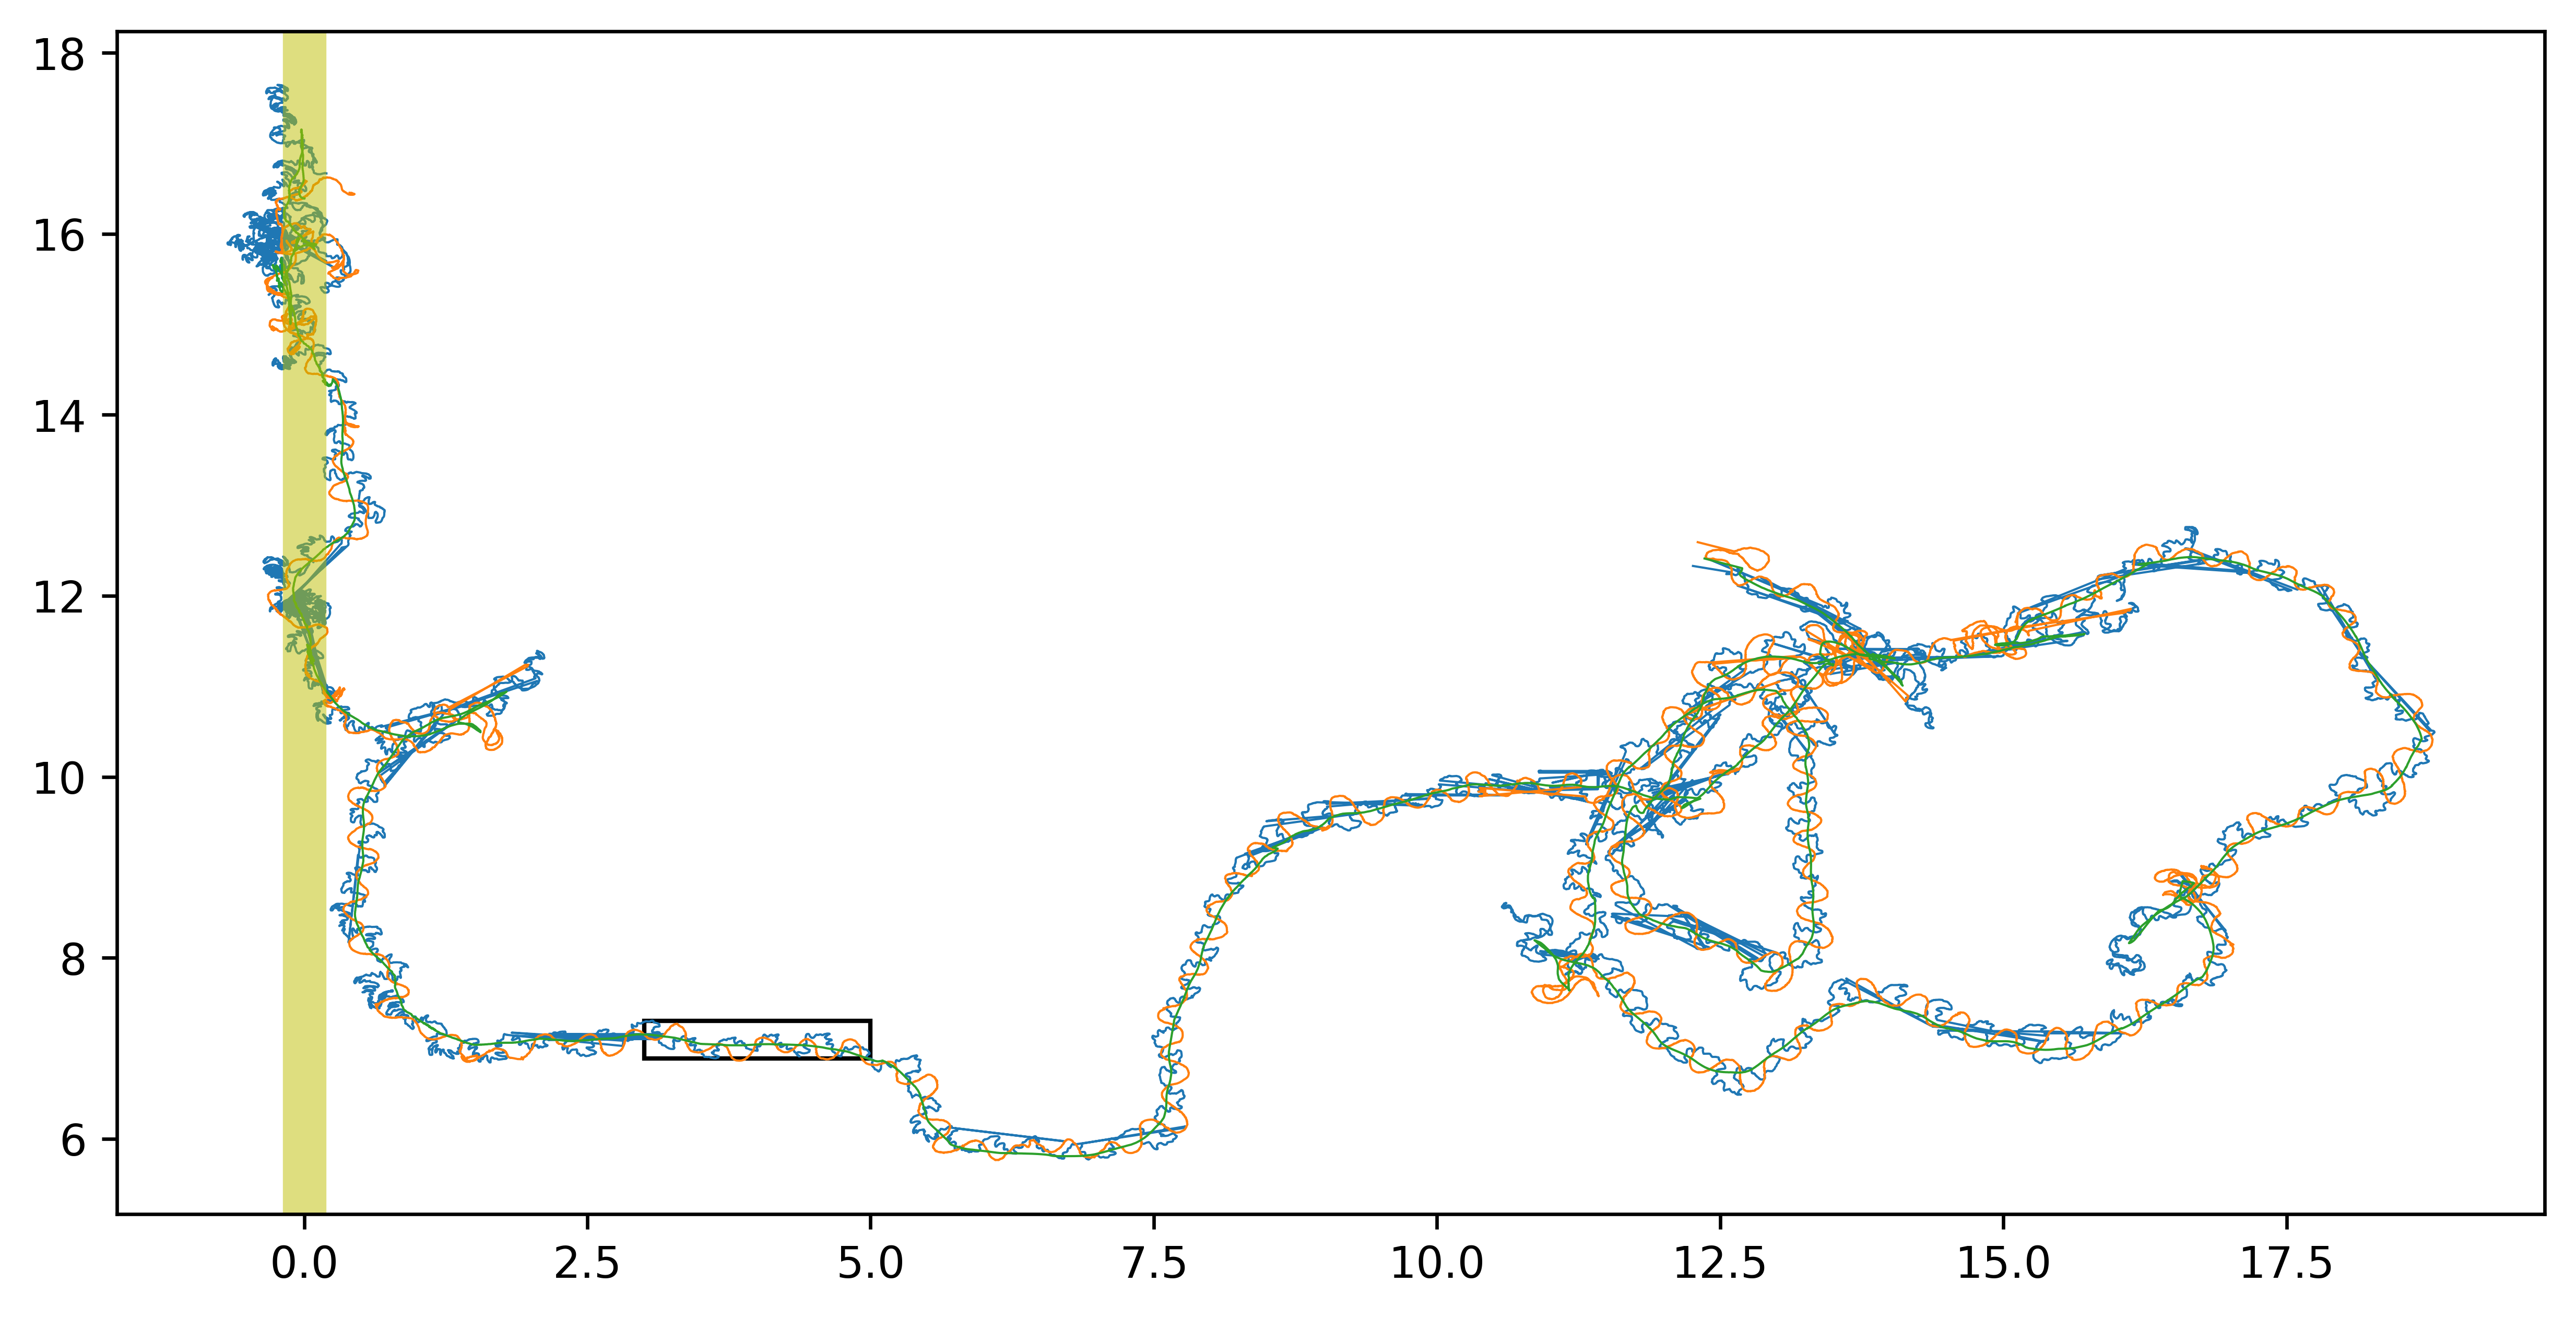

92999 98800


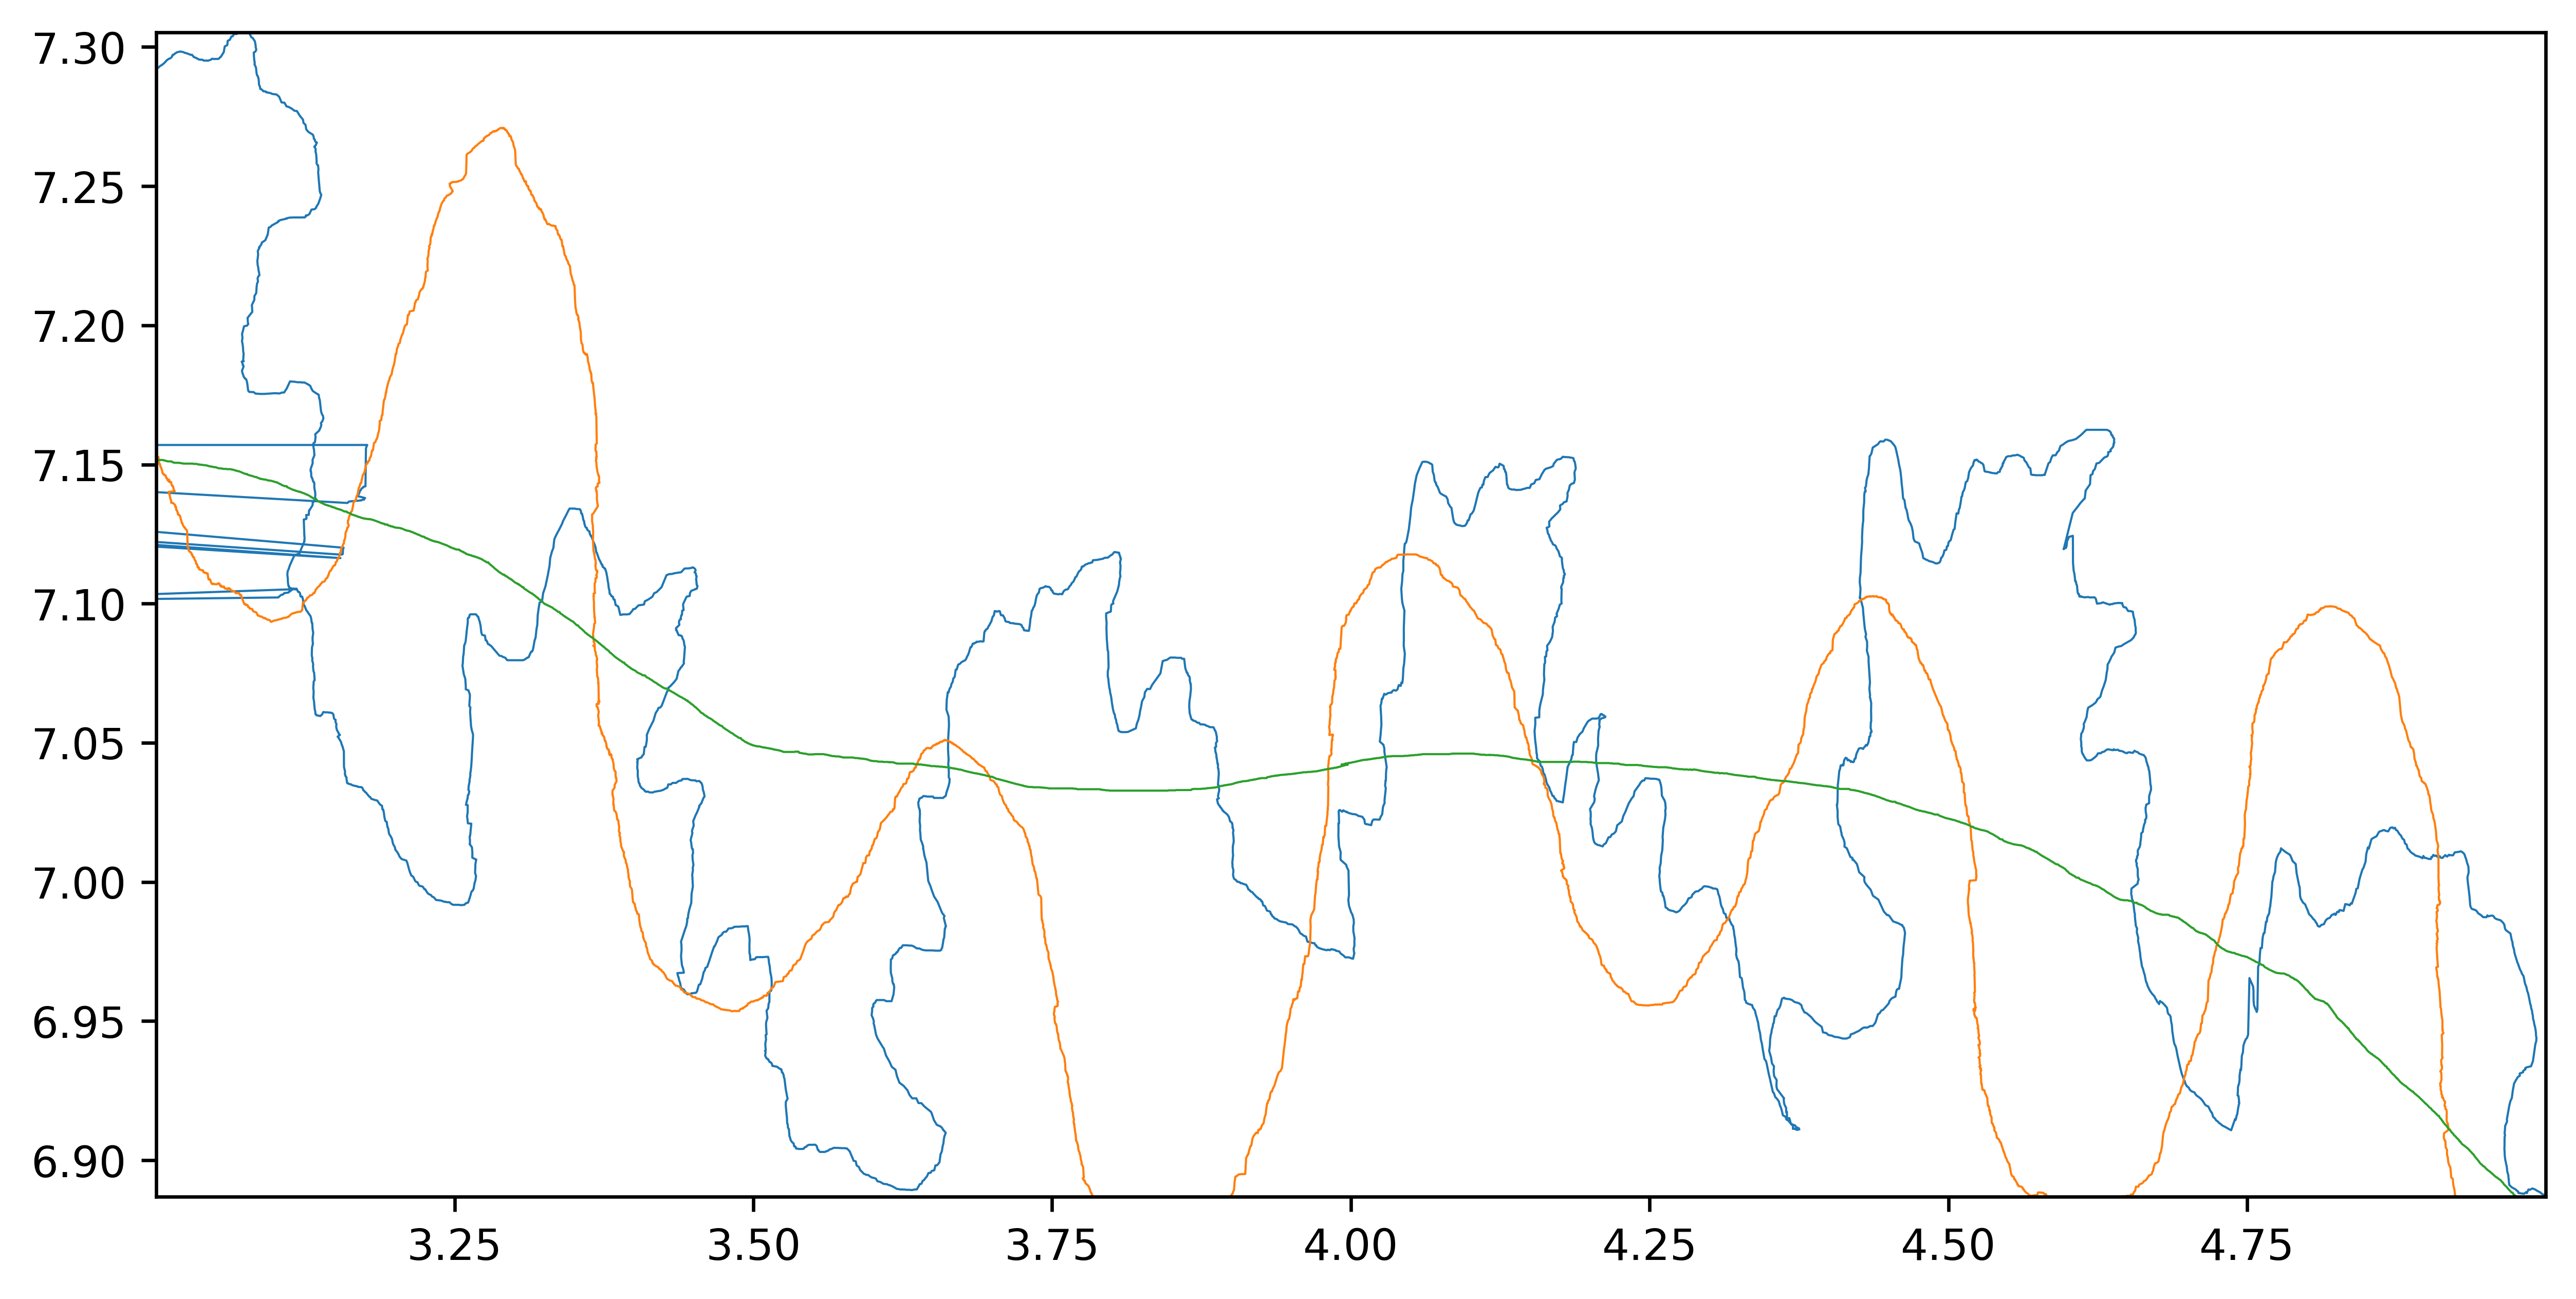

In [8]:
figsize_x=10
figsize_y=5
line_width=0.5

#plot track
head_pos_x=concentration_change['x_head_corrected']
tail_pos_x=concentration_change['x_tail_corrected']
center_pos_x=concentration_change['x_center']

head_pos_y=concentration_change['y_head_corrected']
tail_pos_y=concentration_change['y_tail_corrected']
center_pos_y=concentration_change['y_center']

fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
ax3.plot(head_pos_x,head_pos_y,linewidth=line_width)
ax3.plot(tail_pos_x,tail_pos_y,linewidth=line_width)
ax3.plot(center_pos_x,center_pos_y,linewidth=line_width)
ax3.axvline(x=0, ymin=0, ymax=1, lw=10, alpha=.5, color='y')
rect = patches.Rectangle((position['x_head_corrected'].min(), position['y_head_corrected'].min()),
    abs(position['x_head_corrected'].min()-position['x_head_corrected'].max()), abs(position['y_head_corrected'].min()-position['y_head_corrected'].max()), linewidth=1, edgecolor='k', facecolor='none')
ax3.add_patch(rect)
plt.show()
#determining part for zoom
fig2, ax2 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
ax2.plot(head_pos_x,head_pos_y,linewidth=line_width)
ax2.plot(tail_pos_x,tail_pos_y,linewidth=line_width)
ax2.plot(center_pos_x,center_pos_y,linewidth=line_width)
plt.xlim(position['x_head_corrected'].min(),position['x_head_corrected'].max())
plt.ylim(position['y_head_corrected'].min(),position['y_head_corrected'].max())
ax2.axvline(x=0, ymin=0, ymax=1, lw=10, alpha=.5, color='y')
print(position.index.min(), position.index.max())
plt.show()

In [9]:
#load data
#csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_13-21-00_chemotaxisl_worm1_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]

In [10]:
start_frame=position.index.min()
end_frame=position.index.max()
fps=167.0 #frames per second
Ks=K[start_frame:end_frame]
print(('lenght of recording:'+str((end_frame-start_frame)/fps)+" secs")) #defines the part of the track i want to fourier transform
print(Ks.shape)

lenght of recording:34.73652694610779 secs
(5801, 100)


In [45]:
#averaging over multiple segments
win=1 #number of segments averaged (1 for single segments)
K_avg = pd.DataFrame(K) #convert to df to perform the groupy function
Kt_avg=K_avg.T
Kt_avg=Kt_avg.groupby(Kt_avg.index // win).mean() #takes the average of 5 segments resulting in 20 rows
print('number of rows and columns:'+str(Kt_avg.shape))
Kt_avg=Kt_avg.to_numpy() 
#Kt_avg

number of rows and columns:(100, 197999)


In [46]:
def peaks(Kts,fps,frequency,start_freq,end_freq):
    plt.rcParams.update({'figure.max_open_warning': 0})
    plt.rcParams.update({'font.size': 16})
    N=Kts.shape[1]
    #sample spacing
    T=1.0/fps
    #x=np.linspace(0.0, N*T, N)
    xf=np.linspace(0.0, 1.0//(2.0*T), N//2)


    for idx, segment in enumerate(Kts):
        #print(idx)
        #skip some segments
        #if idx%10!=5:continue
        #if idx >20:continue
    
        y=segment
        yf=scipy.fftpack.fft(y)
        #define axes
        #y_axis (see that it should start at 1 in yf[1:N//2])
        y_axis=2.0/N * np.abs(yf[1:N//2])
        #x_axis
        x_axis=xf[1:N//2]

        #define x and y
        x=np.arange(0, y[start_frame:end_frame].shape[0]/167,1/167)
        y=y[start_frame:end_frame]
    
        #plotting:
        plt.rcParams.update({'figure.max_open_warning': 0})
        plt.rcParams.update({'font.size': 16})
        #oscilations
        plt.figure(figsize=(20,3))
        plt.subplot(1,2,1)
        plt.plot(y)
        peaks, _ = find_peaks(y, height=0,prominence=0.005)
        plt.plot(peaks, y[peaks], "x")
        plt.title('Segment '+str((idx*win))+'-'+str(idx*win+win))
        if idx==0: plt.title('Segment '+str(idx)+'-'+str(win))
        plt.xlabel('Time (s)')
        plt.ylabel('Signal Amplitude (a.u)')

    
        #period
        if frequency==0:
            #period
            plt.subplot(1,2,2)
            plt.plot(1/x_axis, y_axis)
            plt.title('Signal Period at segment '+str((idx*win))+'-'+str(idx*win+win))
            if idx==0: plt.title('Signal Period at Segment '+str(idx)+'-'+str(win))
            plt.xlabel('Period (s)')
            plt.ylabel('Signal Amplitude (a.u)')
        else:
           #Frequency
            plt.subplot(1,2,2)
            plt.plot(x_axis, y_axis)
            plt.xticks(np.arange(start_freq, end_freq, step=1))
            plt.xlim(start_freq,end_freq)
            plt.title('Segment '+str((idx*win))+'-'+str(idx*win+win))
            if idx==0: plt.title('Segment '+str(idx)+'-'+str(win))
            plt.ylabel('Signal Amplitude (a.u)')
            plt.xlabel('Frequency (Hz)')
            #plt.savefig(str(idx)+'.png')
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.3)
            

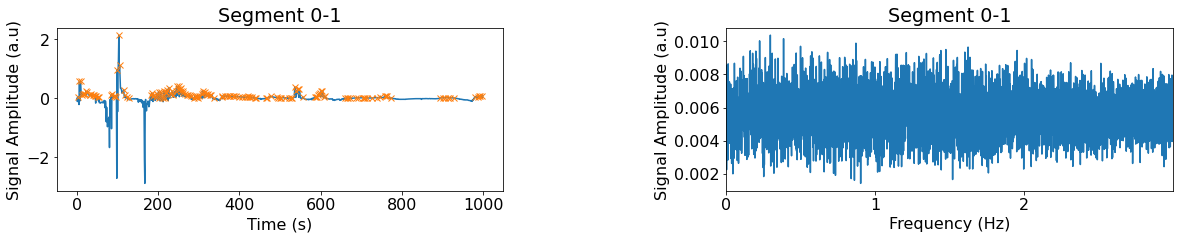

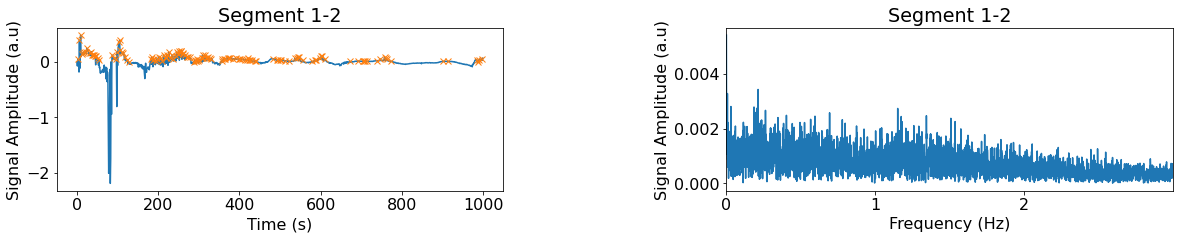

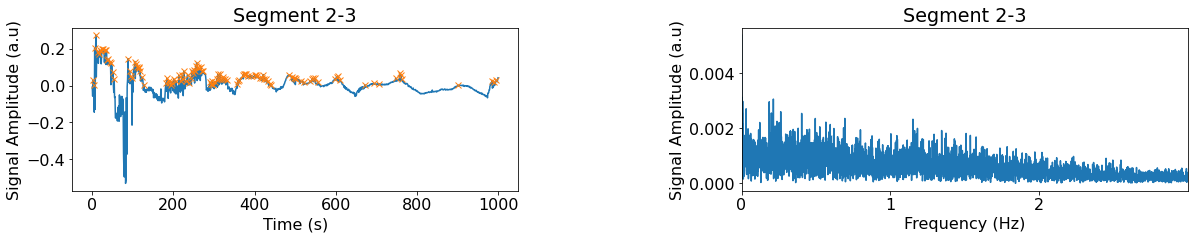

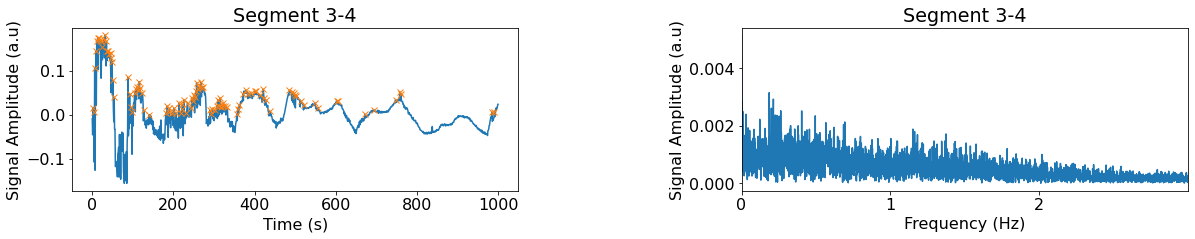

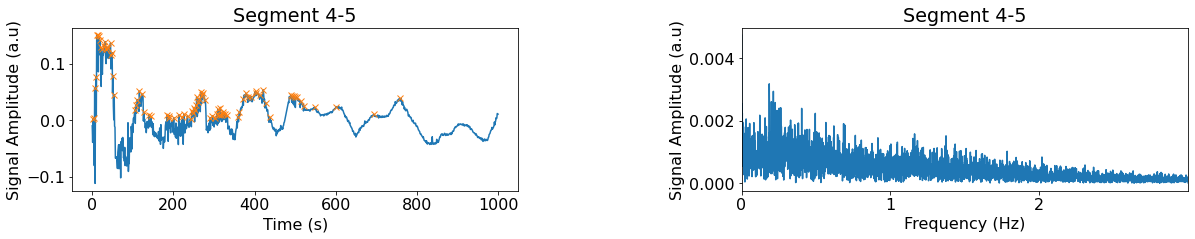

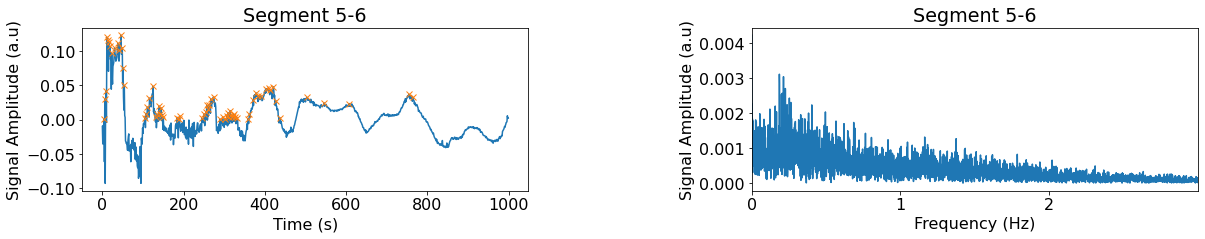

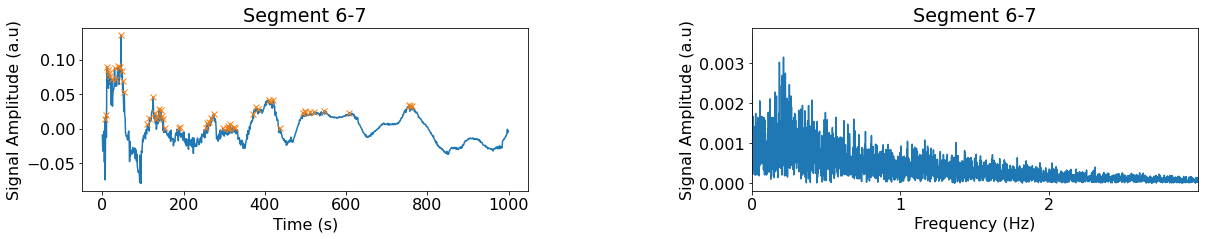

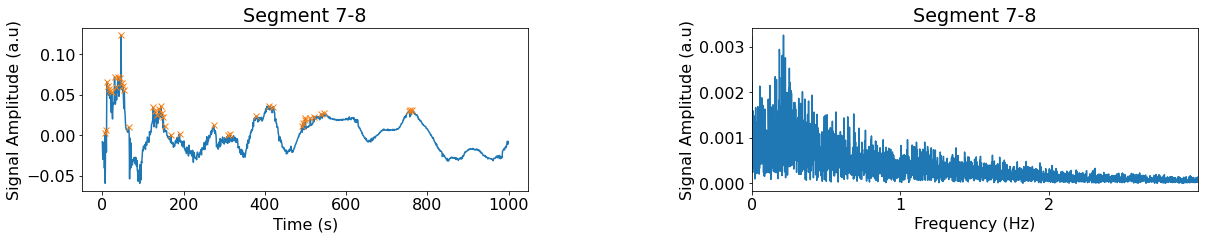

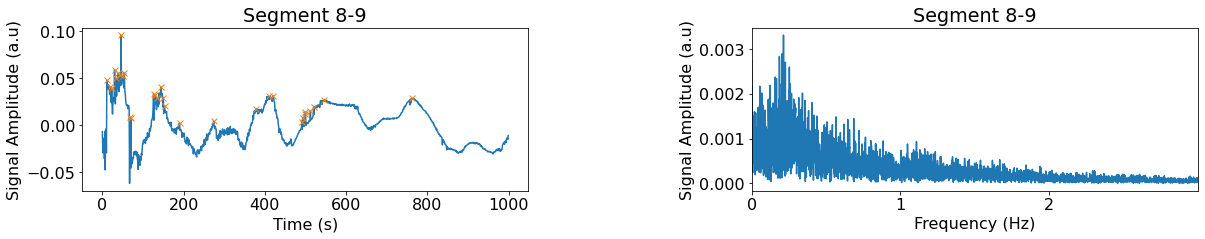

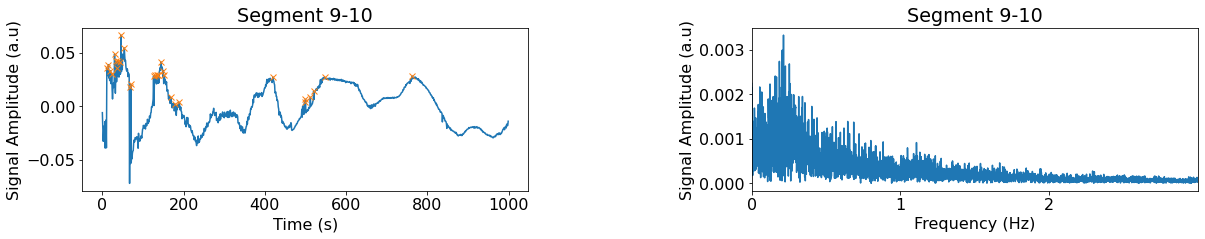

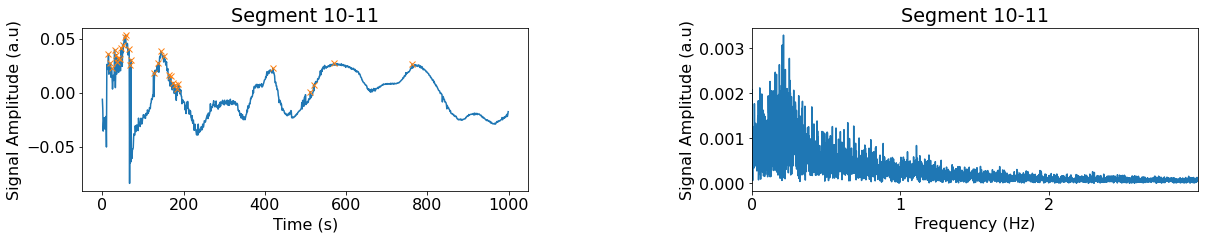

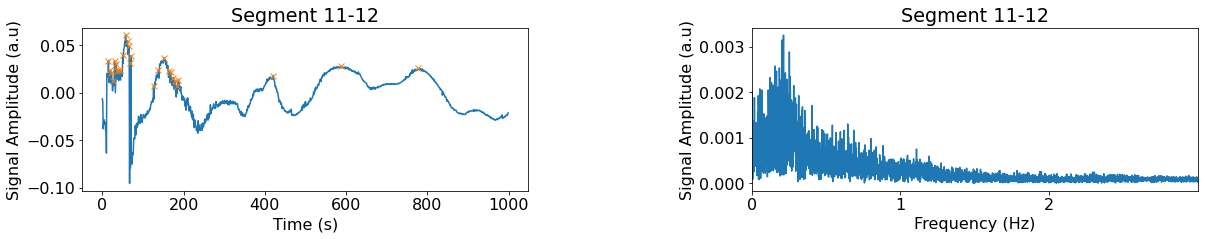

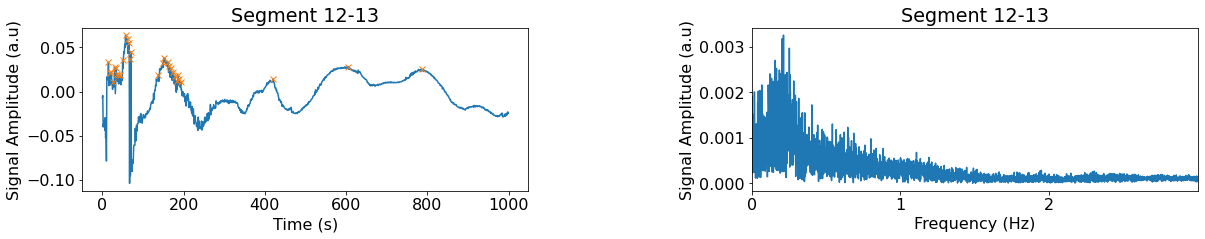

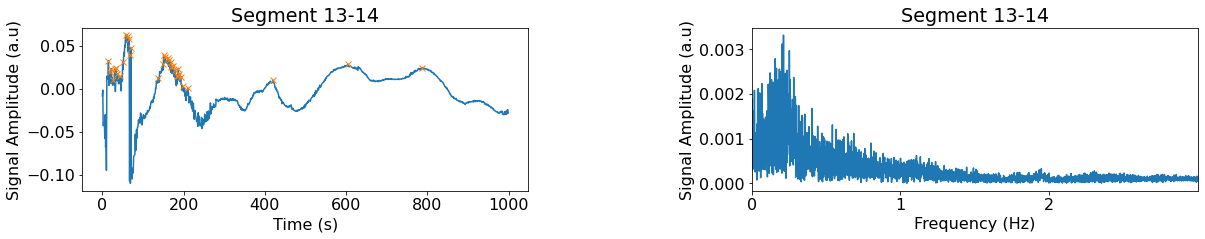

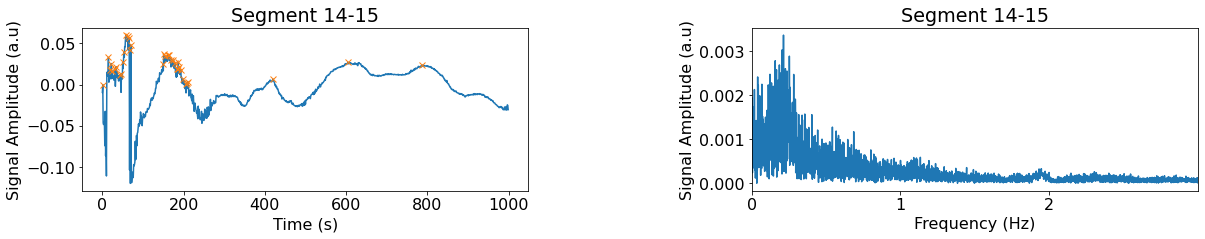

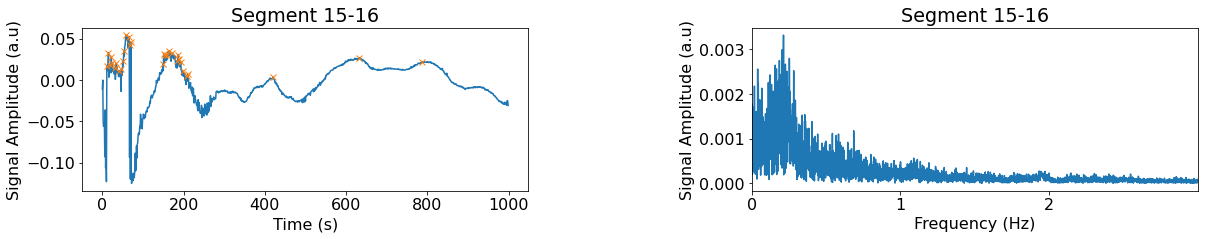

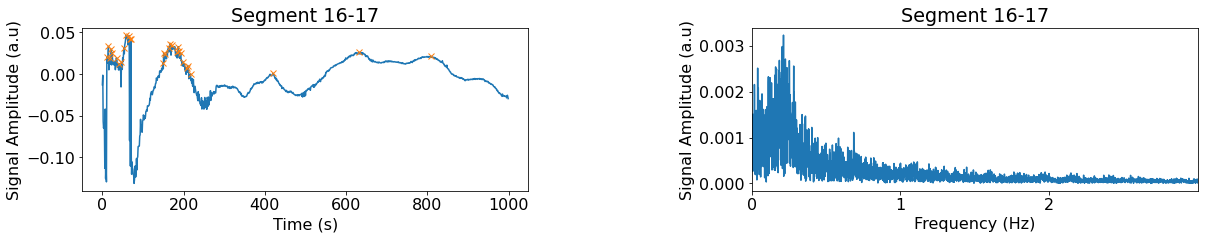

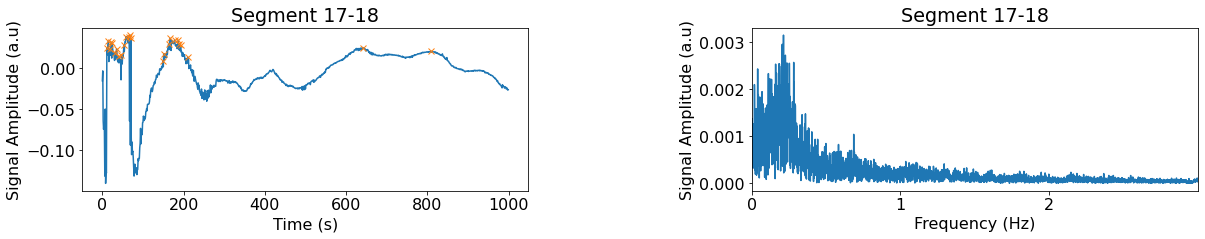

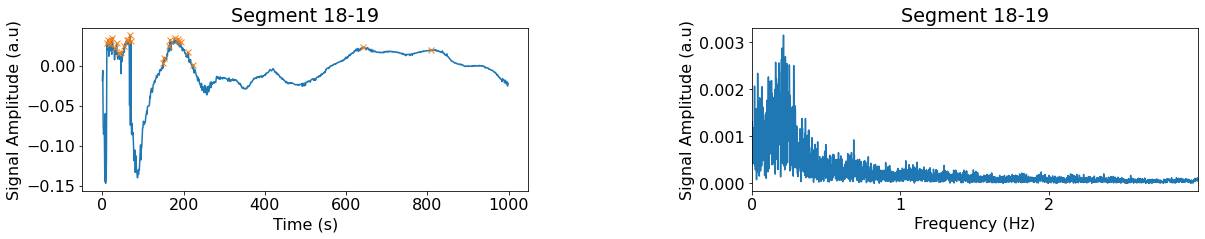

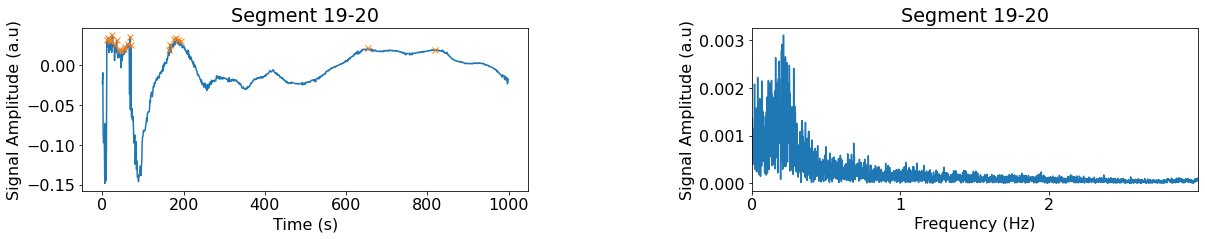

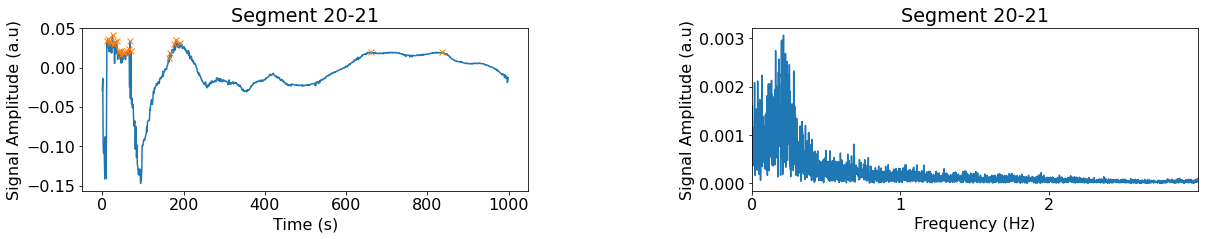

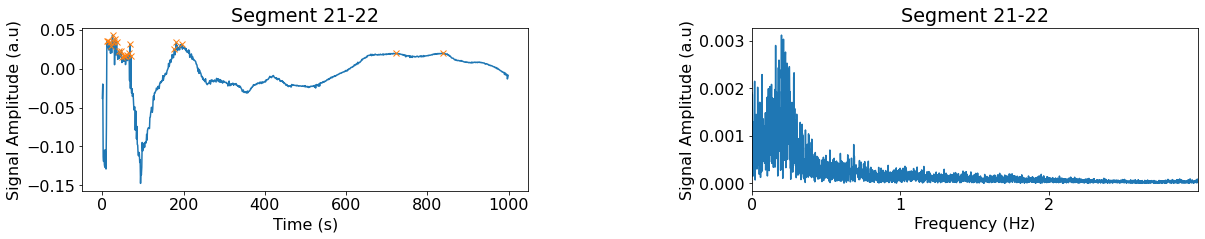

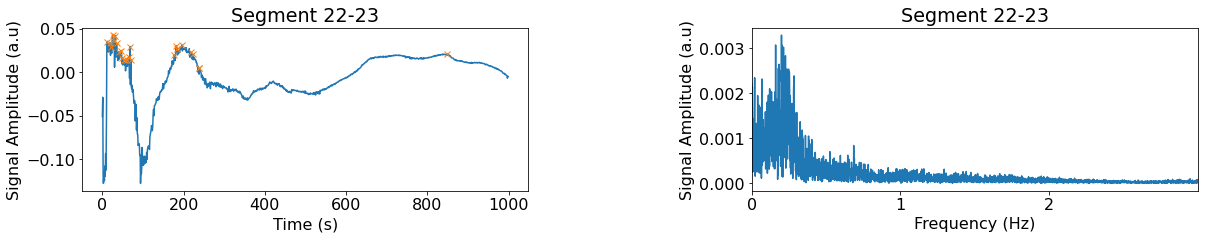

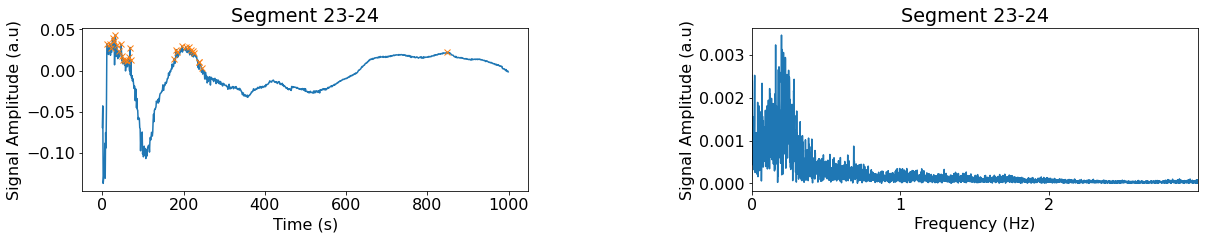

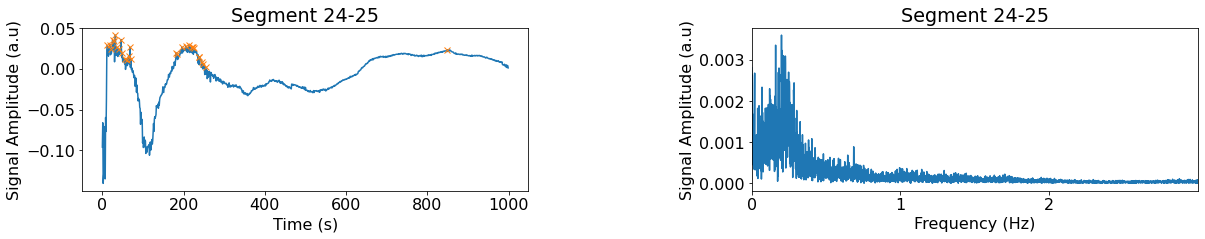

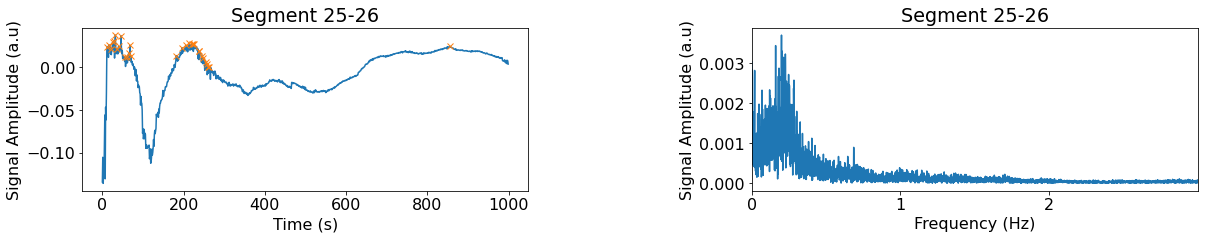

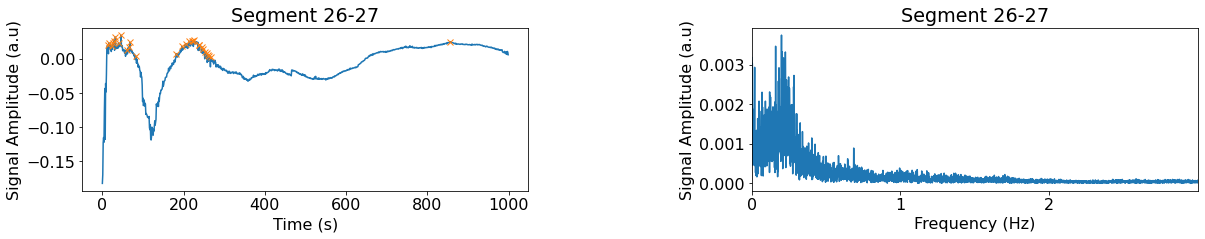

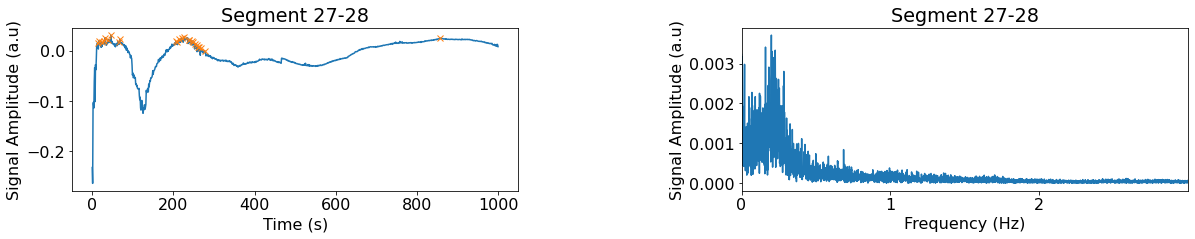

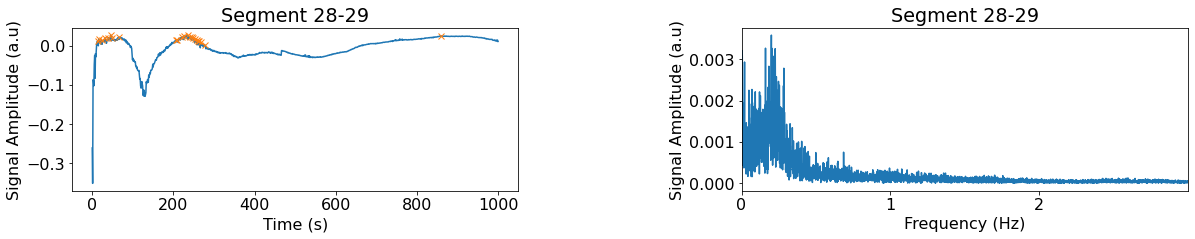

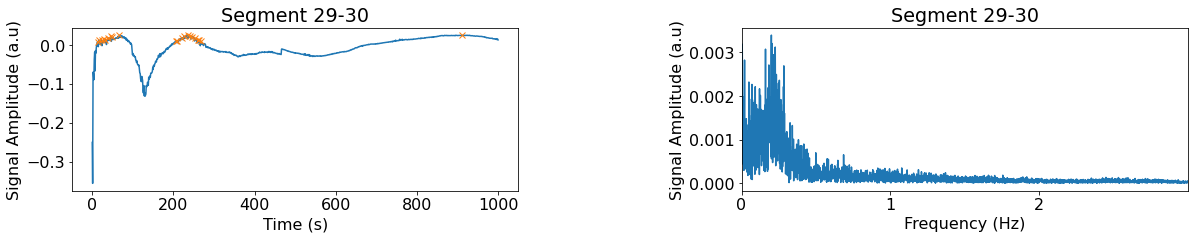

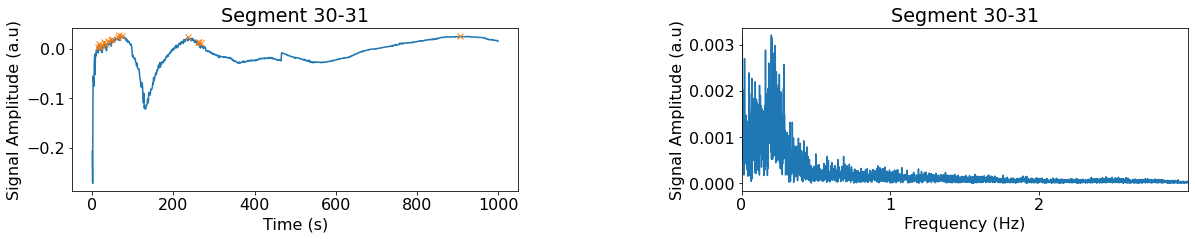

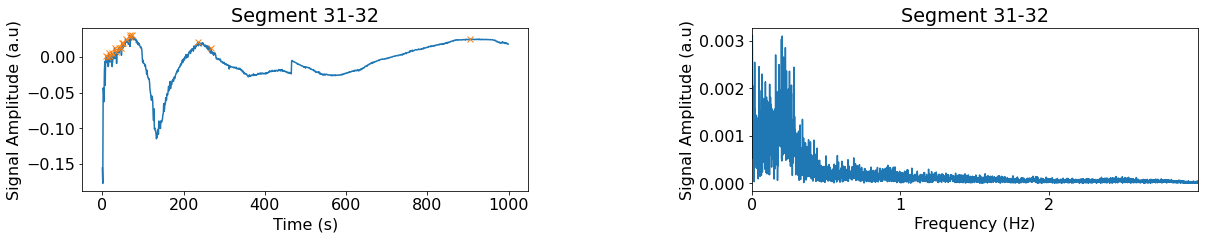

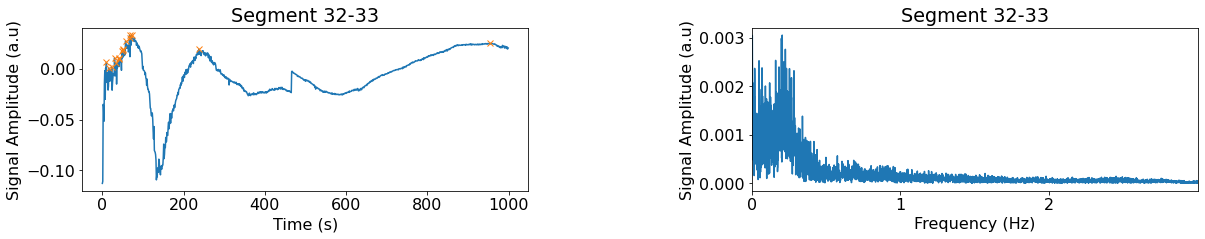

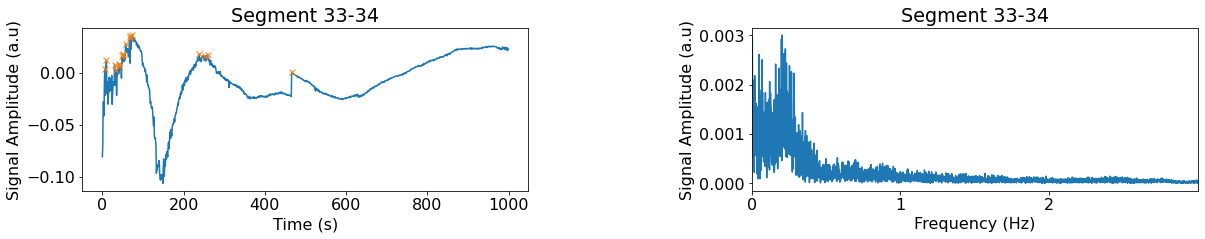

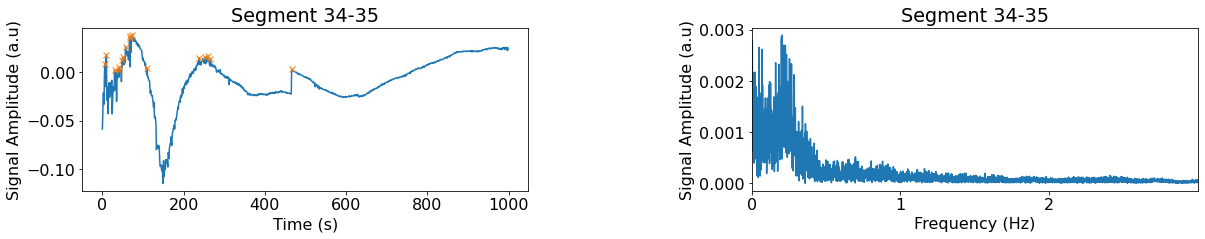

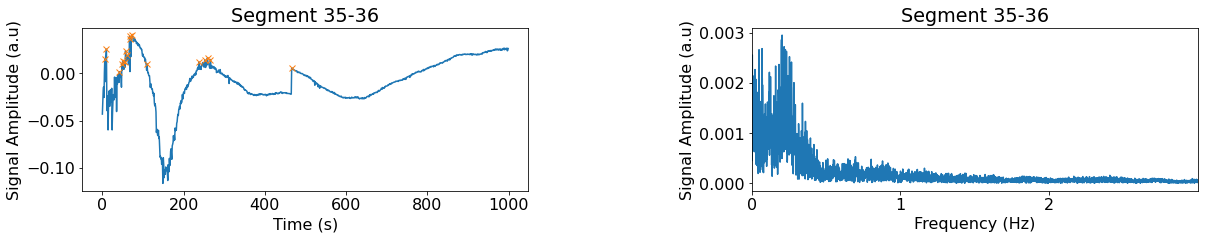

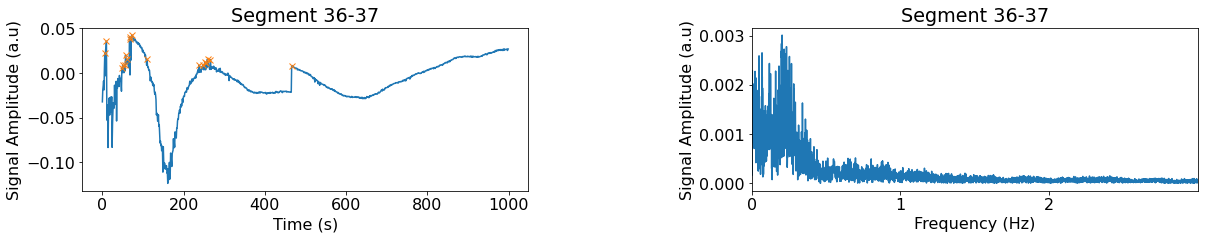

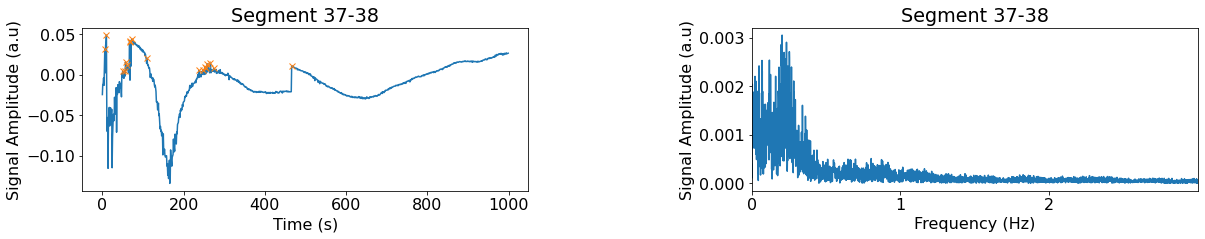

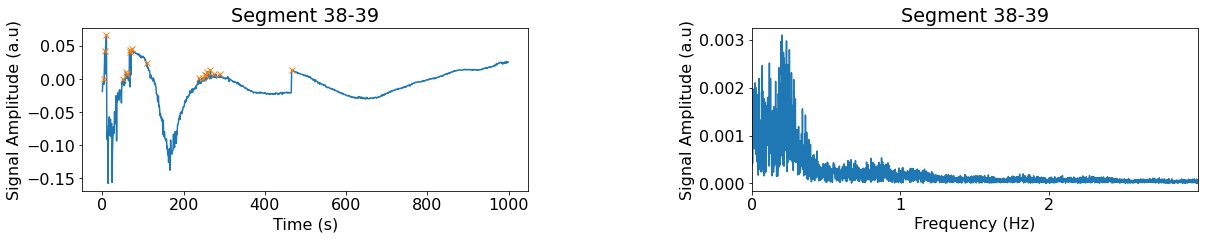

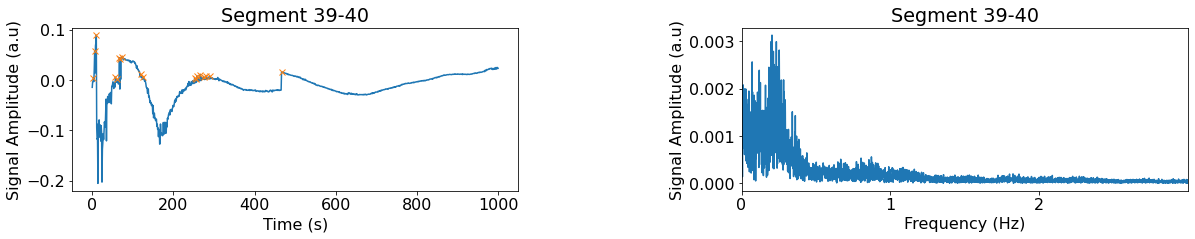

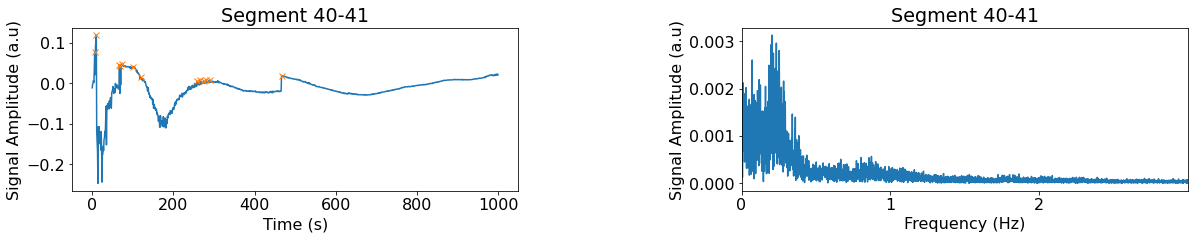

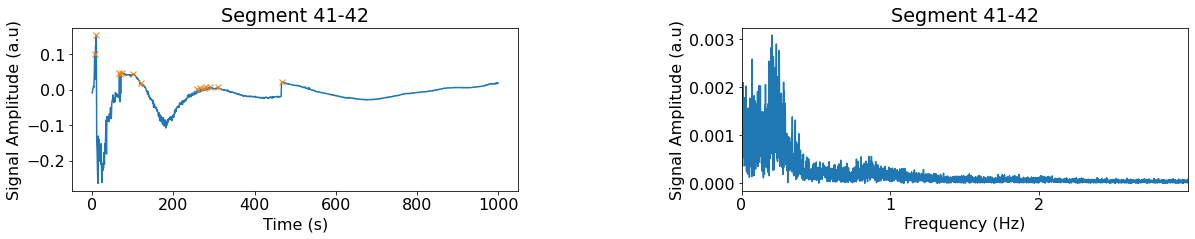

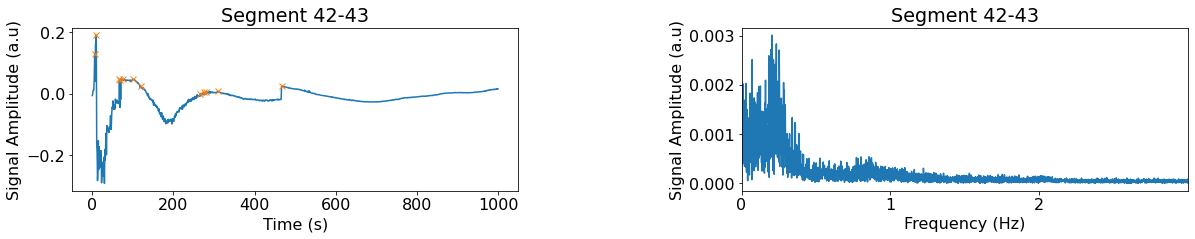

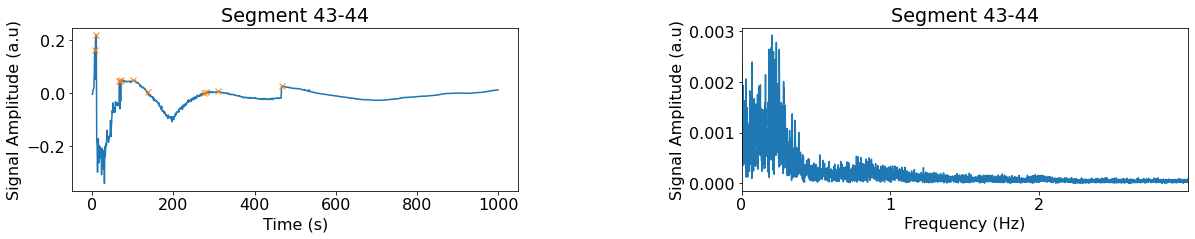

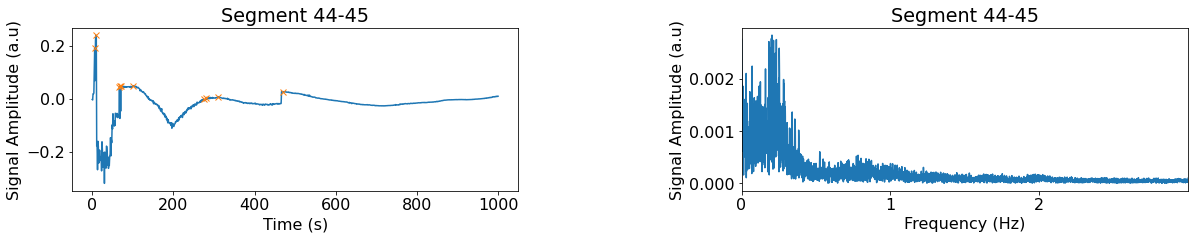

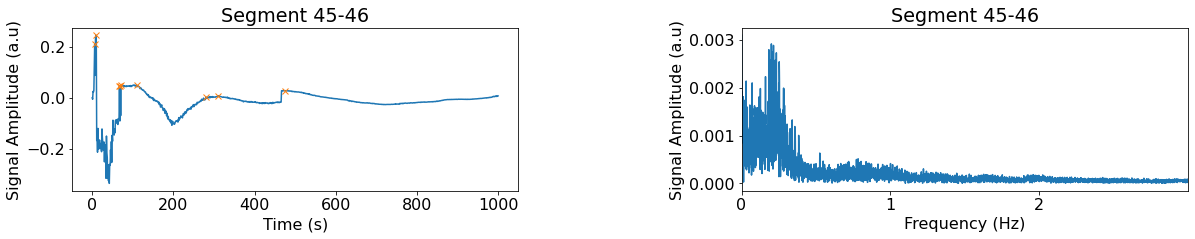

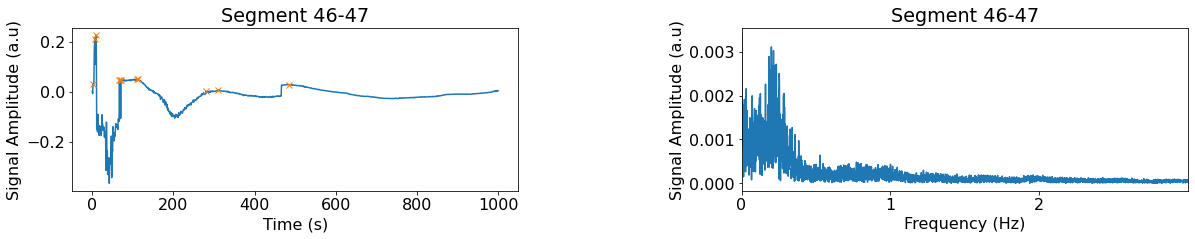

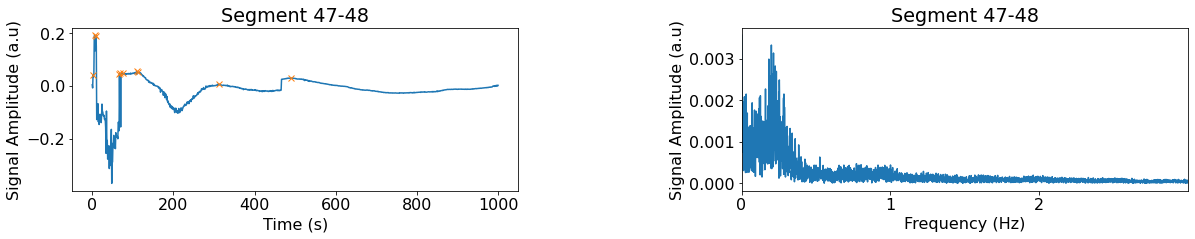

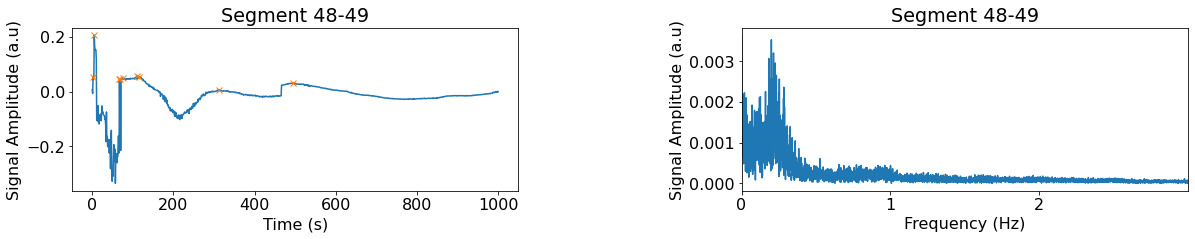

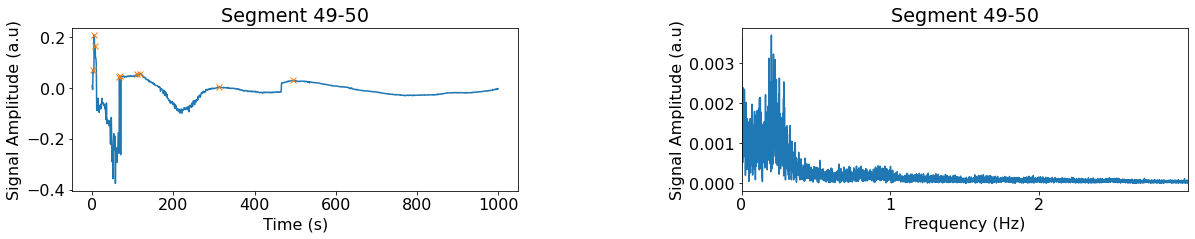

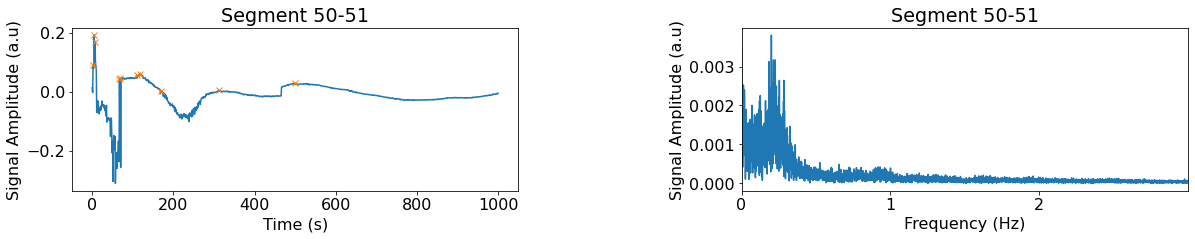

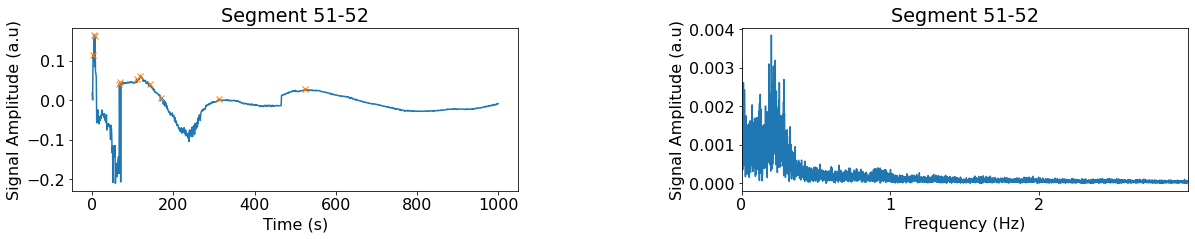

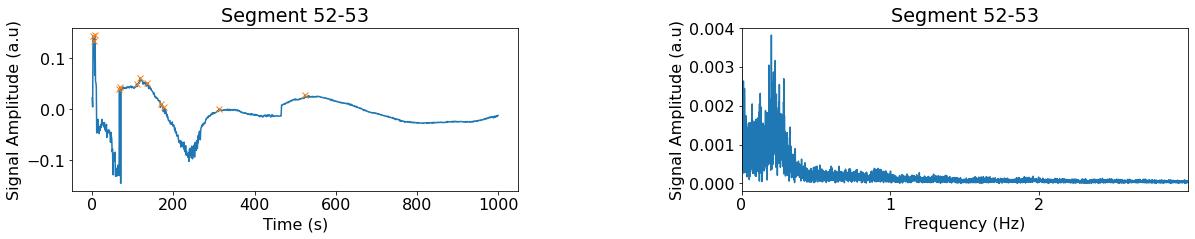

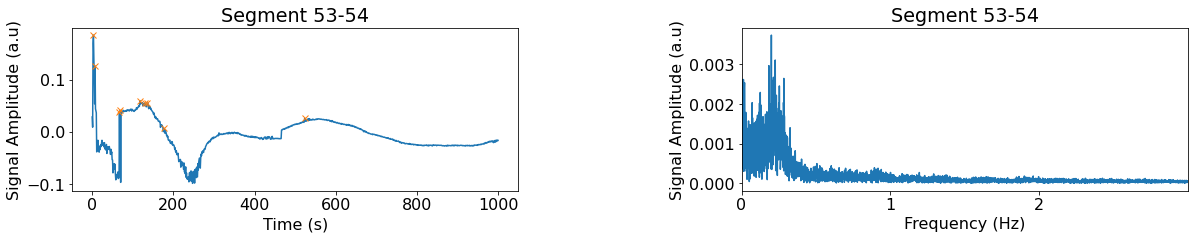

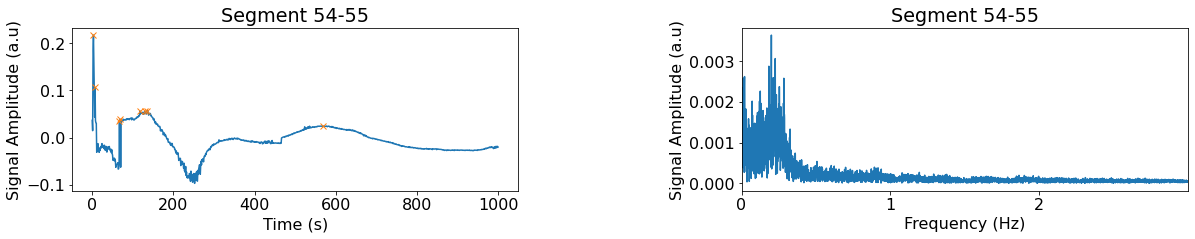

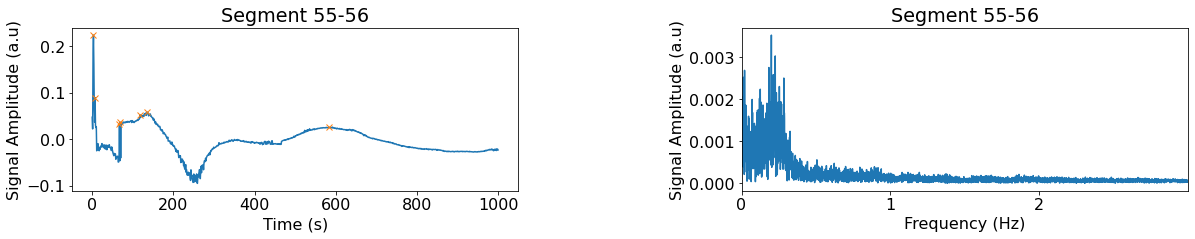

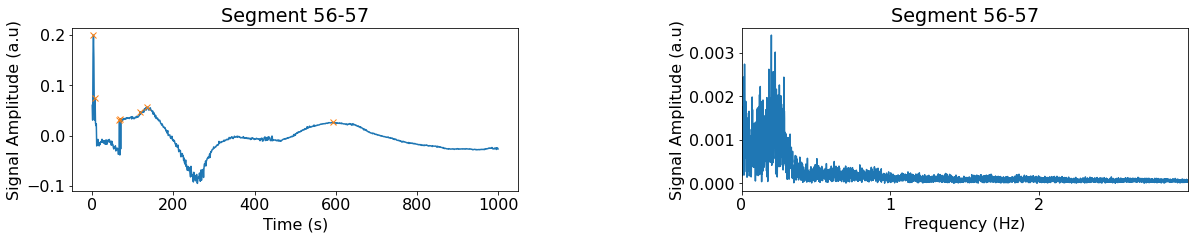

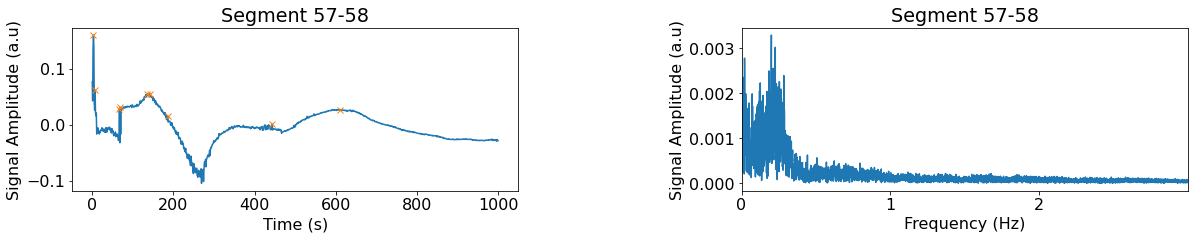

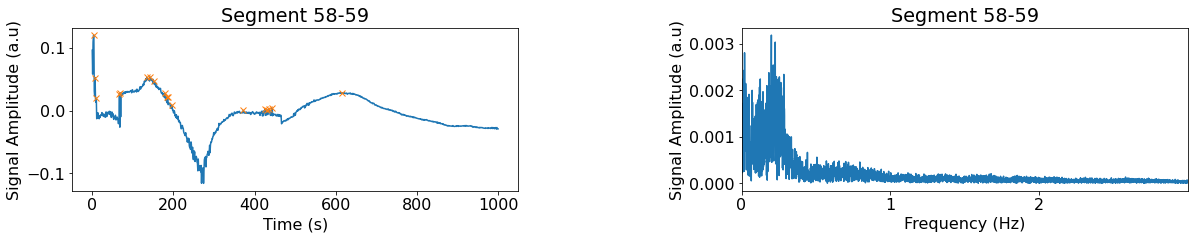

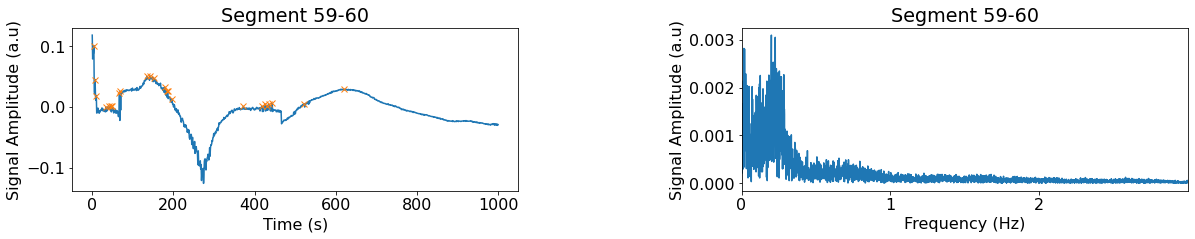

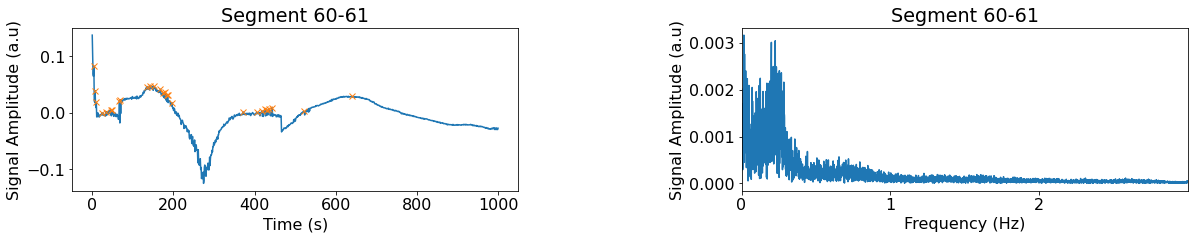

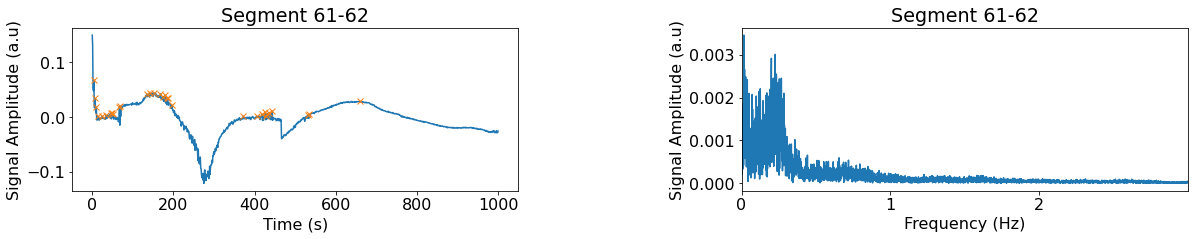

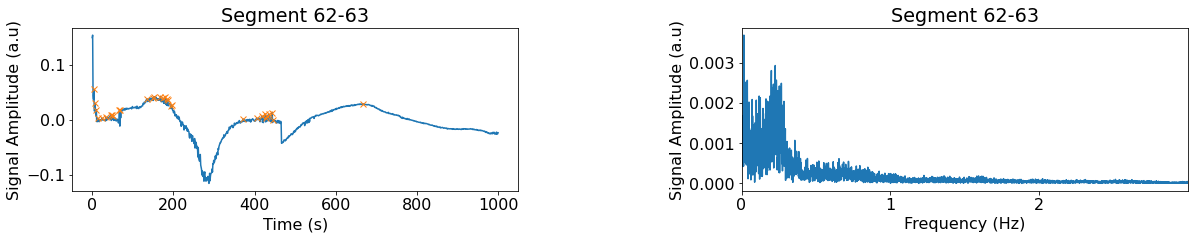

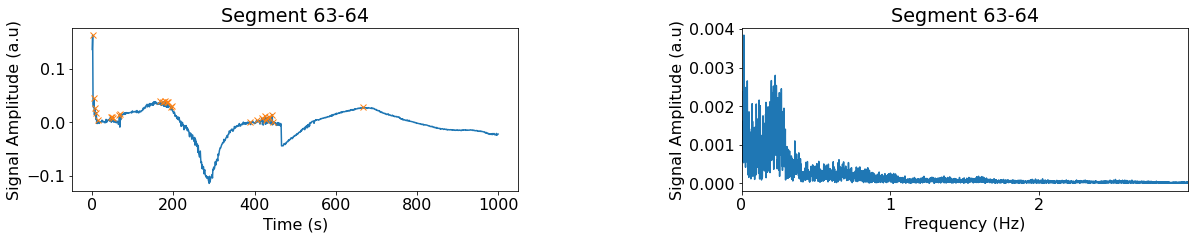

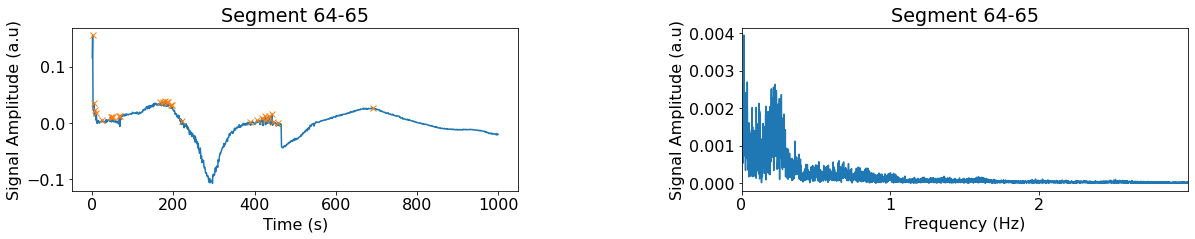

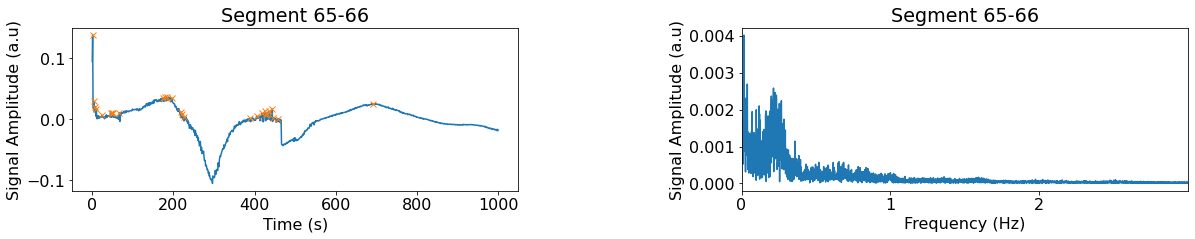

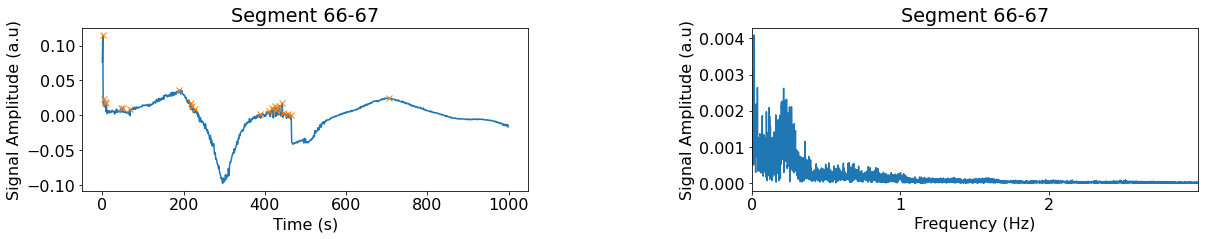

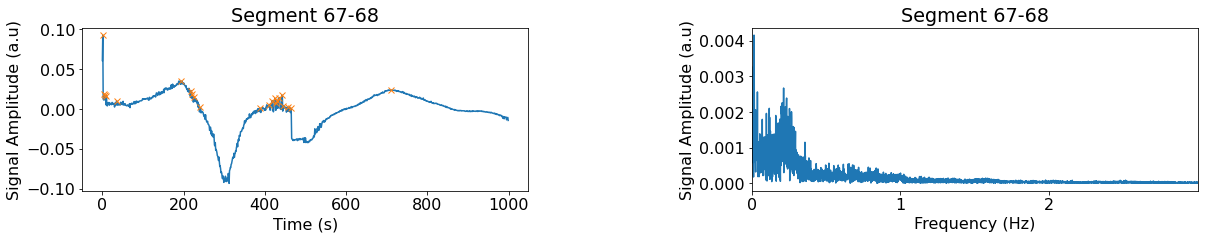

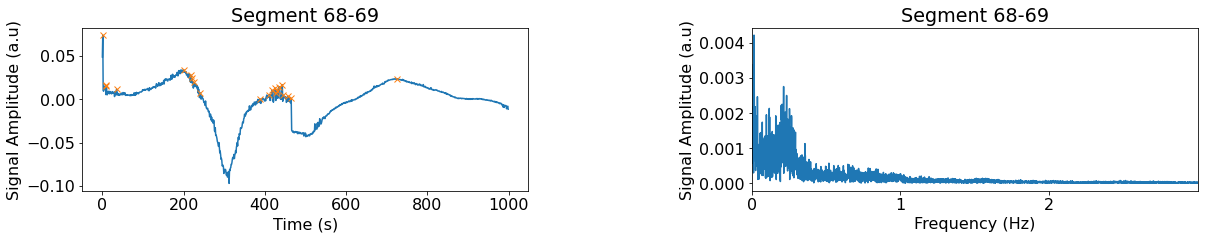

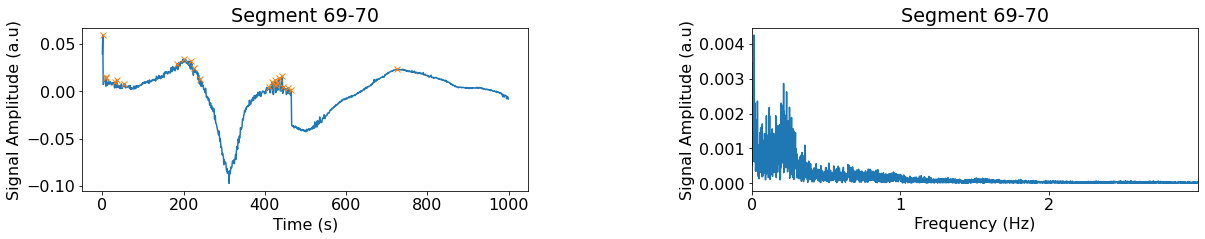

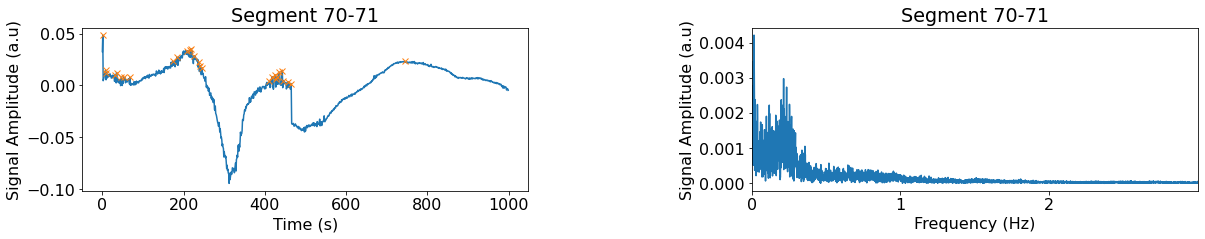

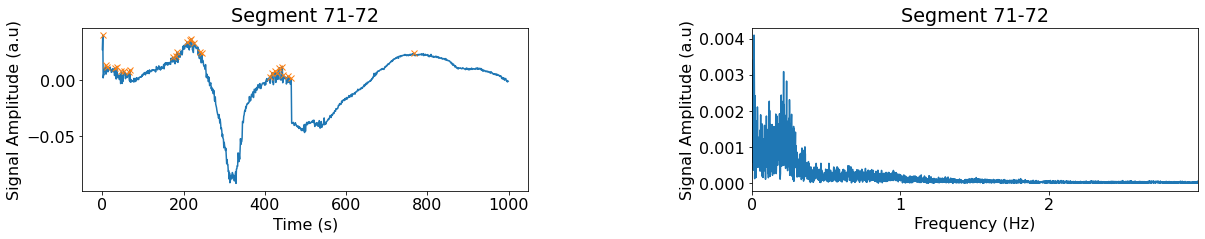

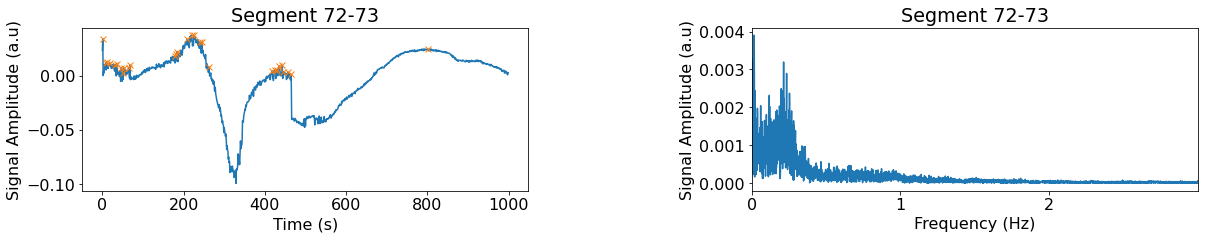

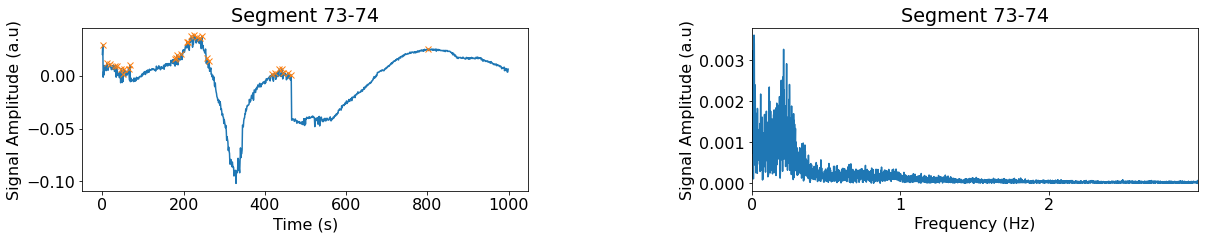

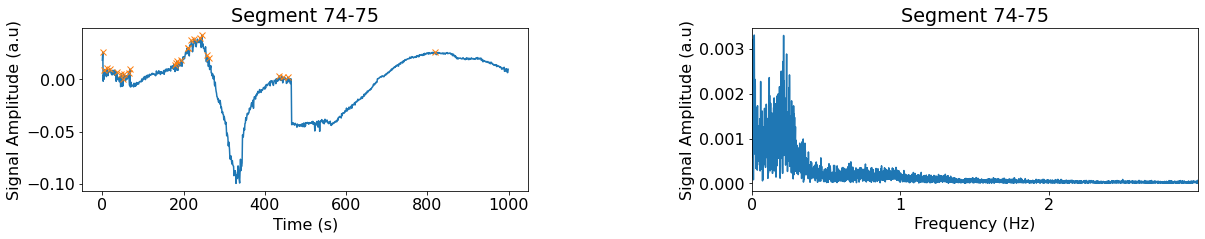

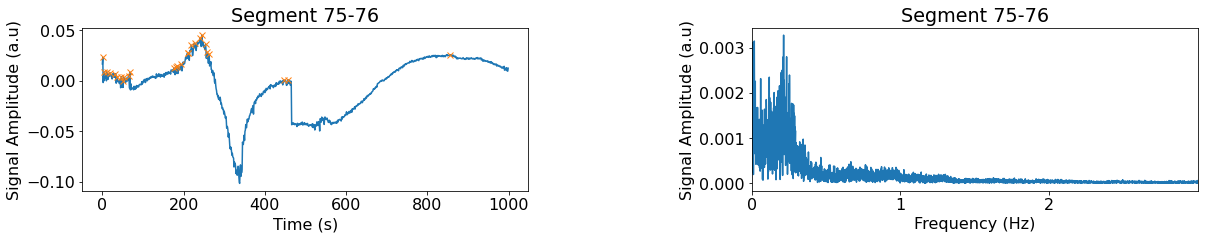

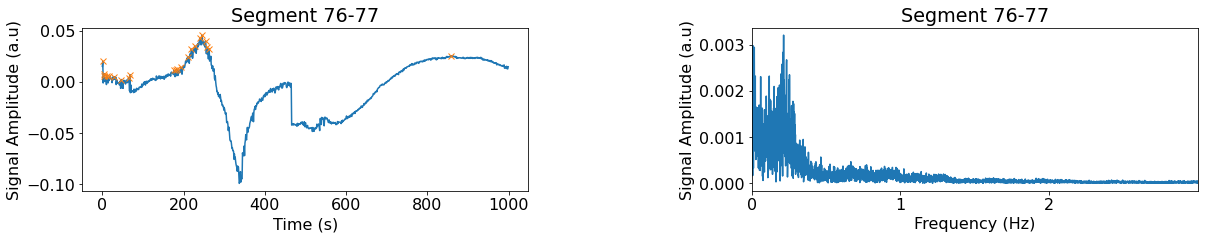

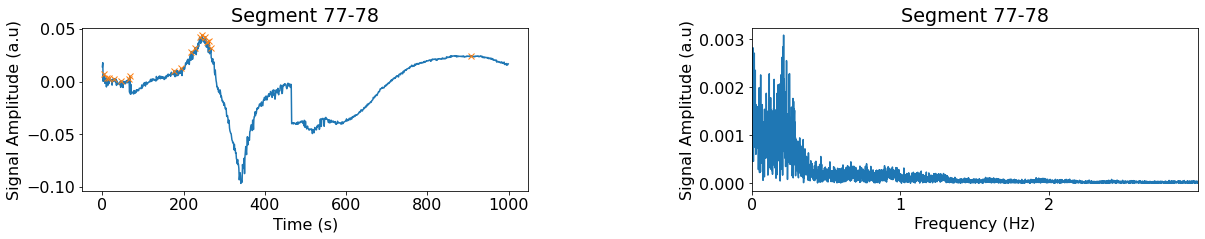

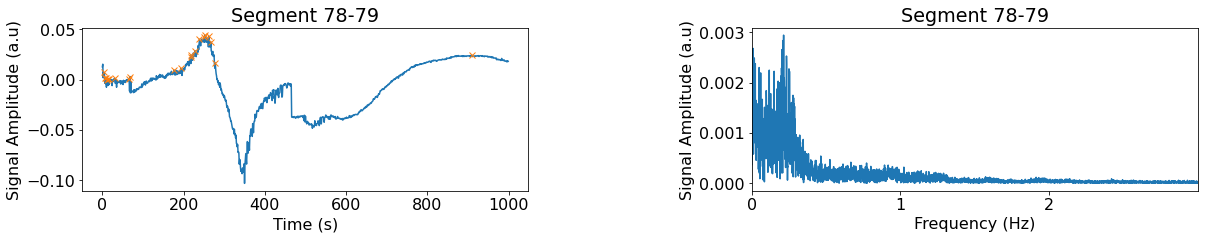

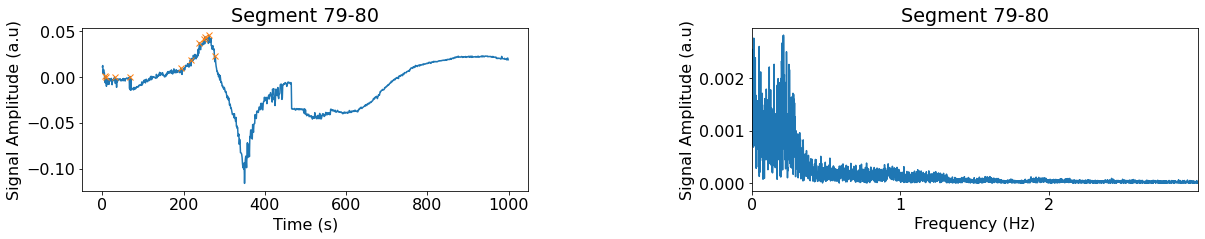

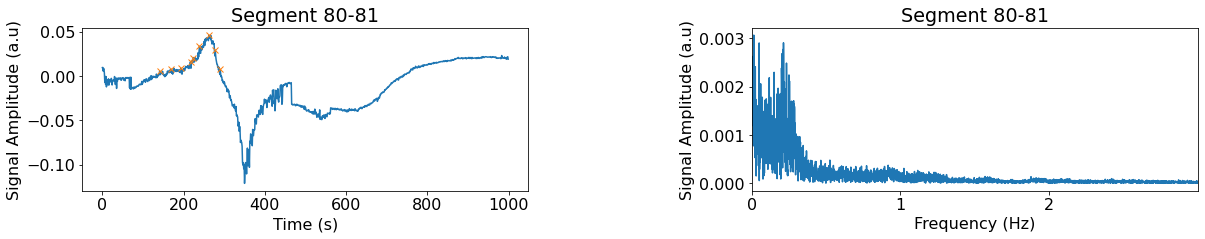

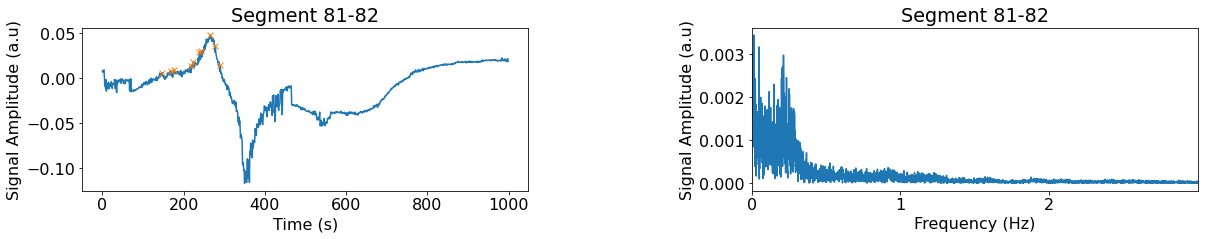

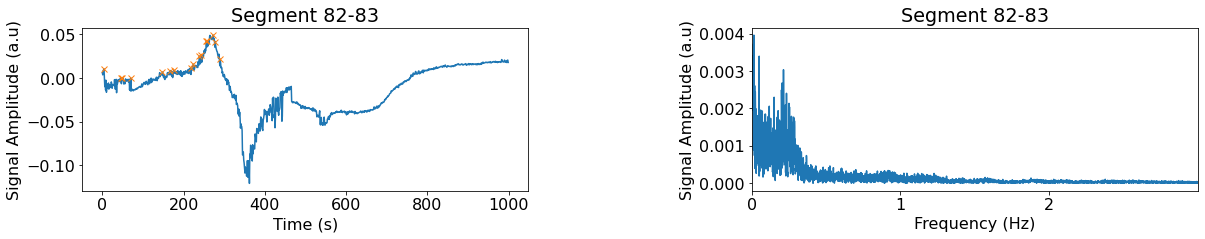

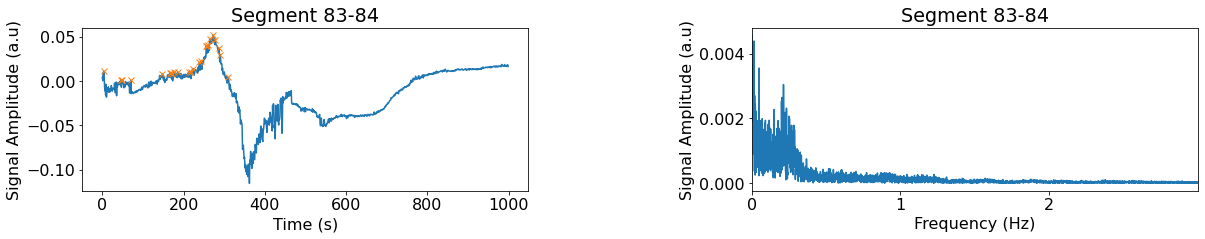

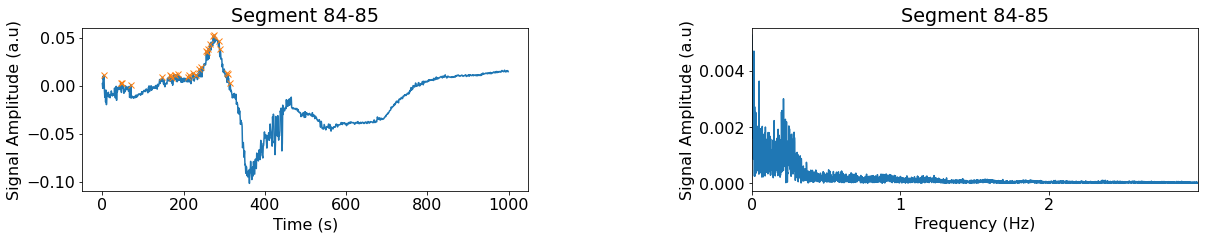

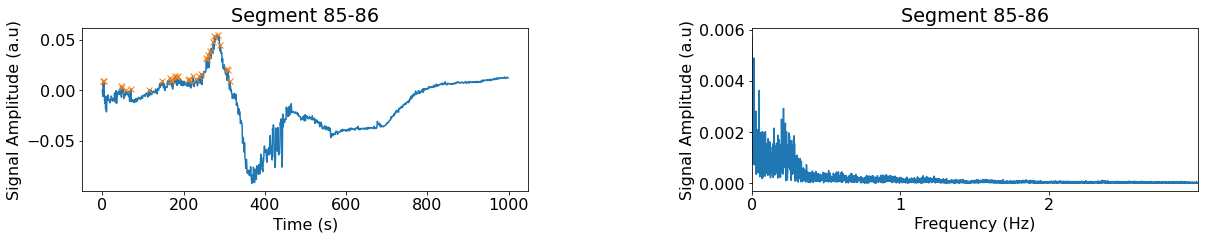

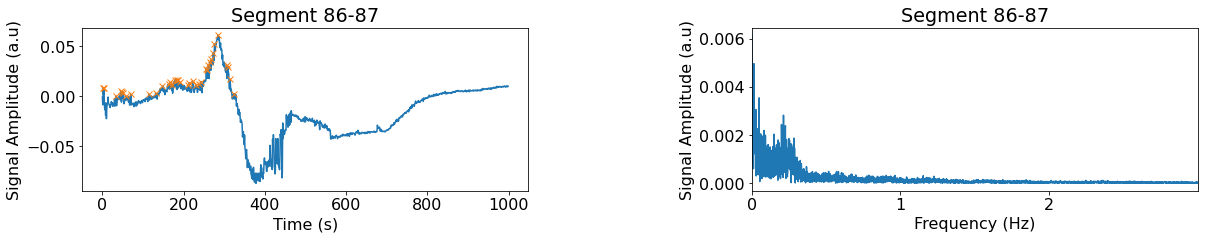

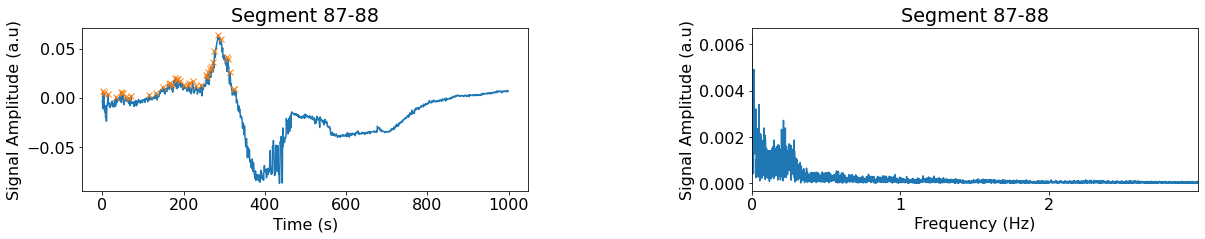

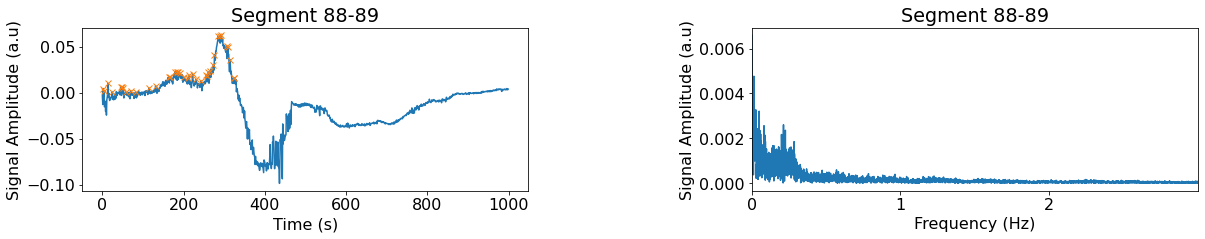

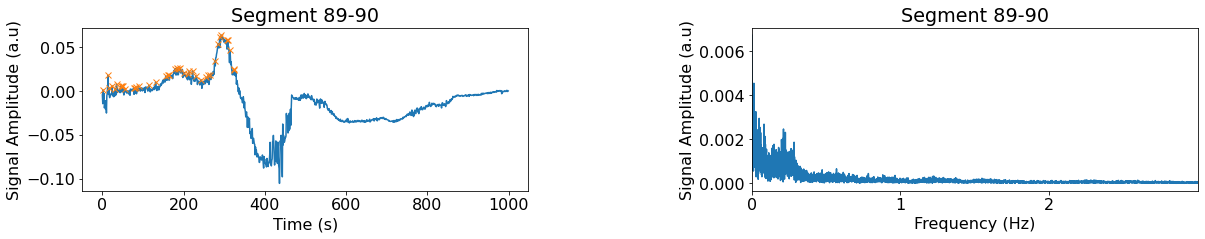

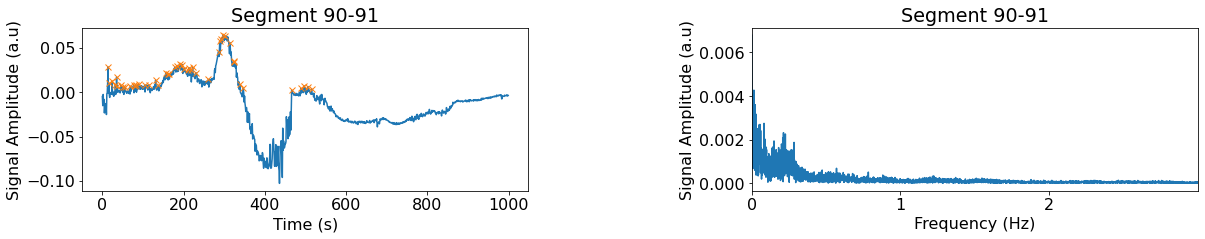

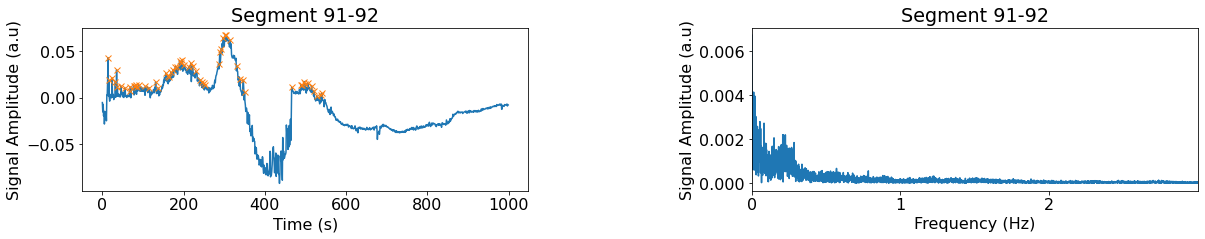

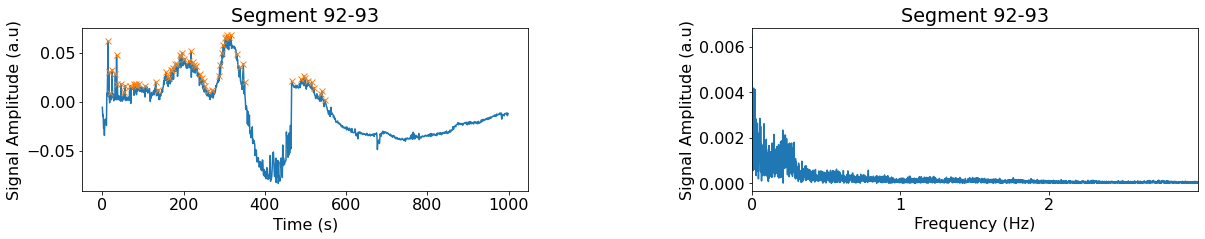

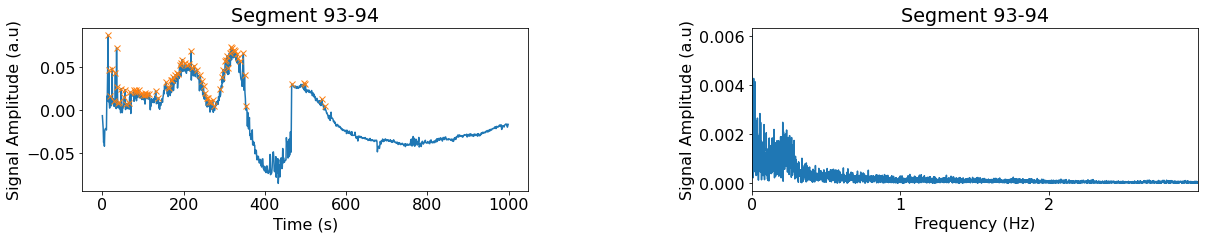

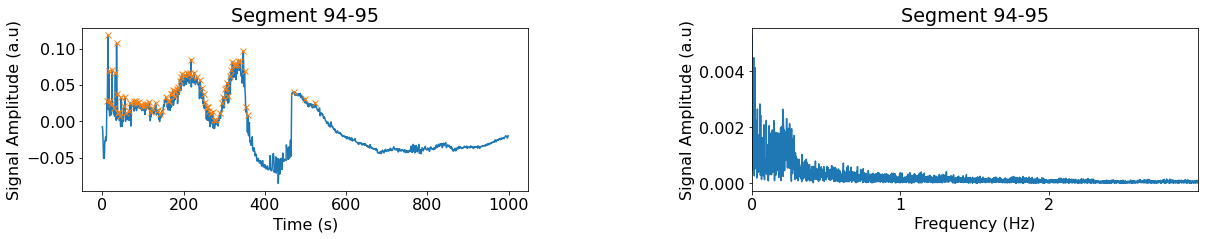

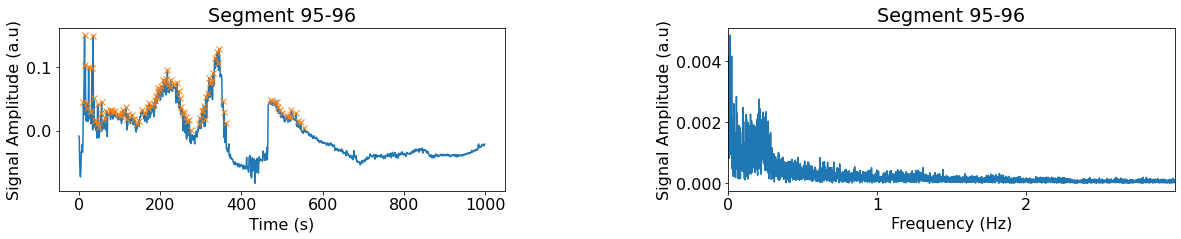

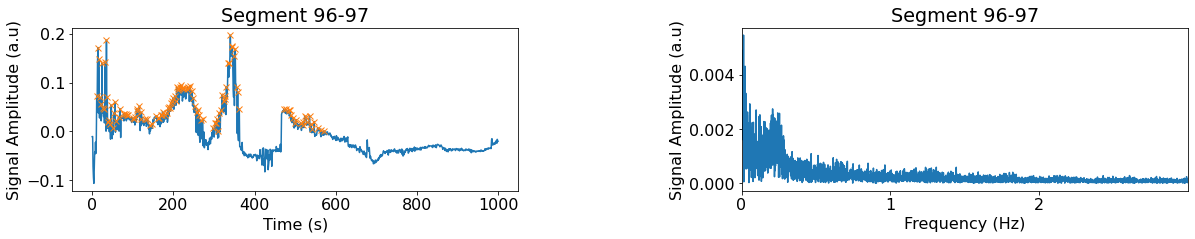

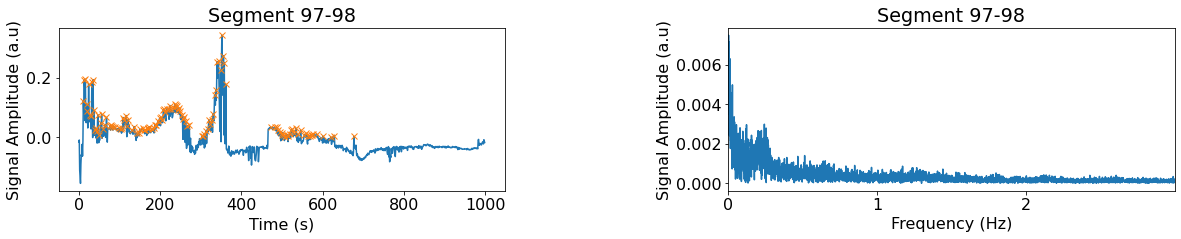

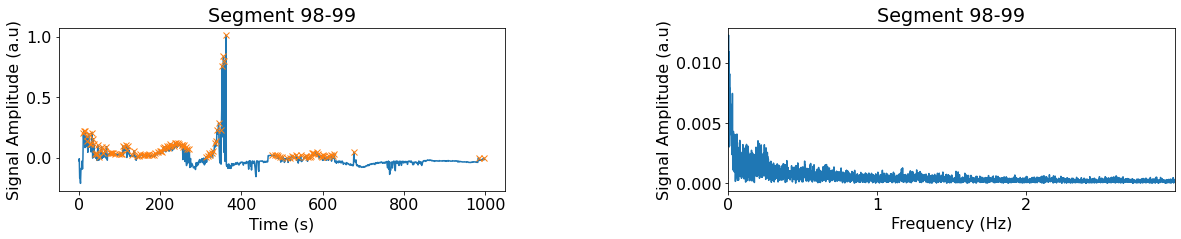

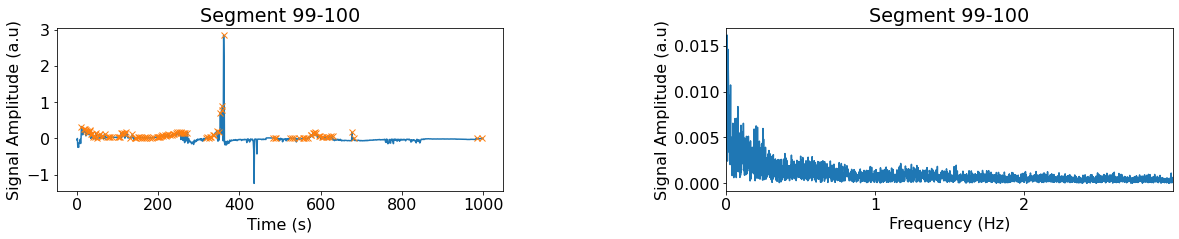

In [47]:
start_frame=0
end_frame=1000
frequency=1
start_freq=0 #range of requencys which should be displayed
end_freq=3 #range of requencys which should be displayed
fps=167.0 #frames per second
peaks(Kt_avg,fps,frequency,start_freq,end_freq)